### Hotel Reservation Prediction

#### Predict weather the customer is going to cancel the reservation or not

#### Load the basic library

In [267]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

#### Load the train CSV

In [268]:
data = pd.read_csv("/Users/bhavasan/learning/ML-Projects/Hotel_Reservation/artifacts/raw/train_data/train.csv")
data.head(5)

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN25630,2,1,2,1,Meal Plan 1,0,Room_Type 1,26,2017,10,17,Online,0,0,0,161.00,0,Not_Canceled
1,INN14474,2,1,1,1,Meal Plan 1,0,Room_Type 1,98,2018,7,16,Online,0,0,0,121.50,2,Not_Canceled
2,INN23721,2,0,0,3,Meal Plan 1,0,Room_Type 1,433,2018,9,8,Offline,0,0,0,70.00,0,Canceled
3,INN05844,2,0,2,5,Meal Plan 1,0,Room_Type 1,195,2018,8,8,Offline,0,0,0,72.25,0,Not_Canceled
4,INN18710,1,0,0,2,Meal Plan 1,0,Room_Type 1,188,2018,6,15,Offline,0,0,0,130.00,0,Canceled


In [269]:
data.columns

Index(['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status'],
      dtype='object')

#### Drop the unwanted columns

In [270]:
data = data.drop(columns=['Booking_ID'],axis=1)

#### Check for null values

In [271]:
data.isnull().sum().sum()

np.int64(0)

#### Check for duplicate values

In [272]:
data.duplicated().sum()

np.int64(7661)

In [273]:
data.drop_duplicates(inplace=True)

In [276]:
df.isnull().sum().sum()

np.int64(0)

#### Examine the columns

In [211]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21359 entries, 0 to 29019
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          21359 non-null  int64  
 1   no_of_children                        21359 non-null  int64  
 2   no_of_weekend_nights                  21359 non-null  int64  
 3   no_of_week_nights                     21359 non-null  int64  
 4   type_of_meal_plan                     21359 non-null  object 
 5   required_car_parking_space            21359 non-null  int64  
 6   room_type_reserved                    21359 non-null  object 
 7   lead_time                             21359 non-null  int64  
 8   arrival_year                          21359 non-null  int64  
 9   arrival_month                         21359 non-null  int64  
 10  arrival_date                          21359 non-null  int64  
 11  market_segment_type 

#### Get categorical and numeric columns

In [ ]:
cat_cols = data.select_dtypes(include='object')
num_cols = data.select_dtypes(include='number')

print(f"Categorical columns: {cat_cols.columns}")
print(f"Numerical columns: {num_cols.columns}")

Categorical columns: Index(['type_of_meal_plan', 'room_type_reserved', 'market_segment_type',
       'booking_status'],
      dtype='object')
Numerical columns: Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests'],
      dtype='object')


### Data analysis

In [213]:
df = data.copy()

In [214]:
len(num_cols.columns)

14

#### Univarient analysis

In [215]:
def num_plot_dist(df, num_cols):
    for col in num_cols:
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution of {col}")
        
        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot of {col}")
        
        plt.tight_layout()
        plt.show()

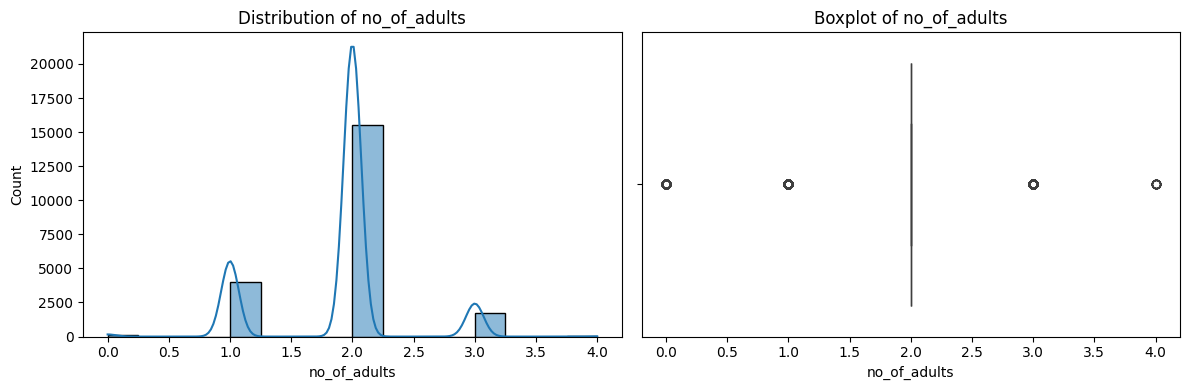

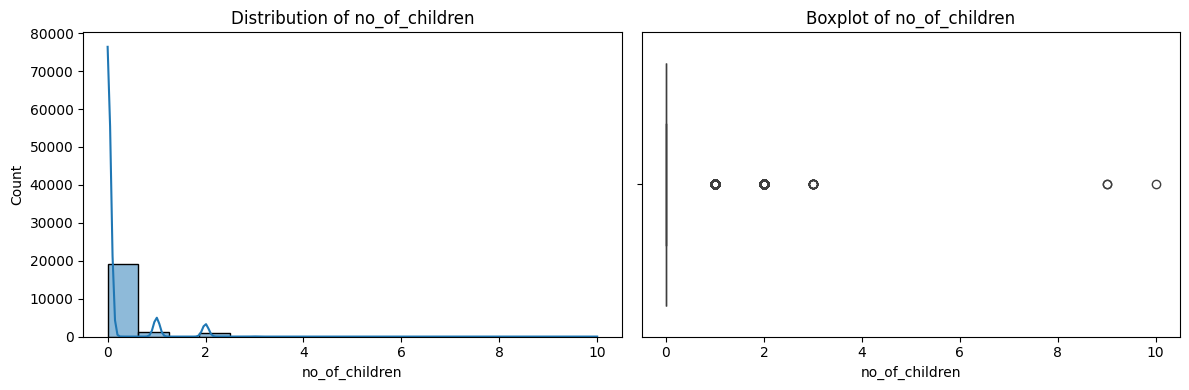

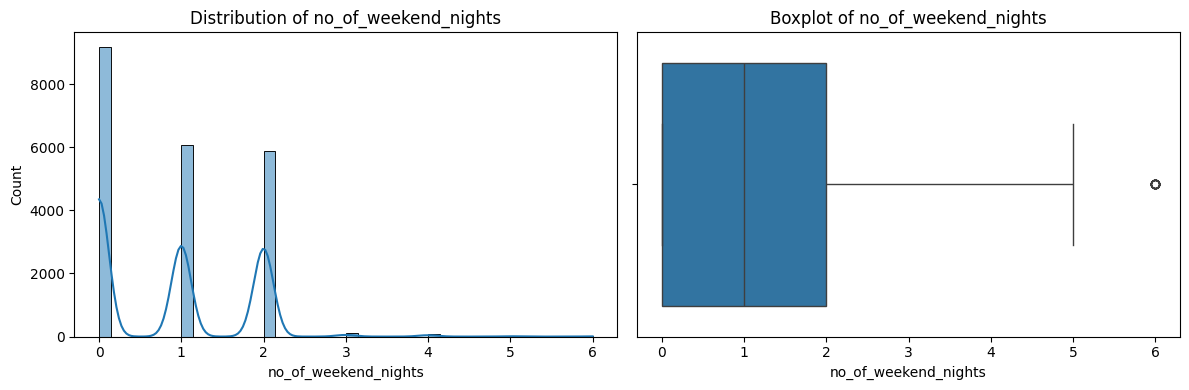

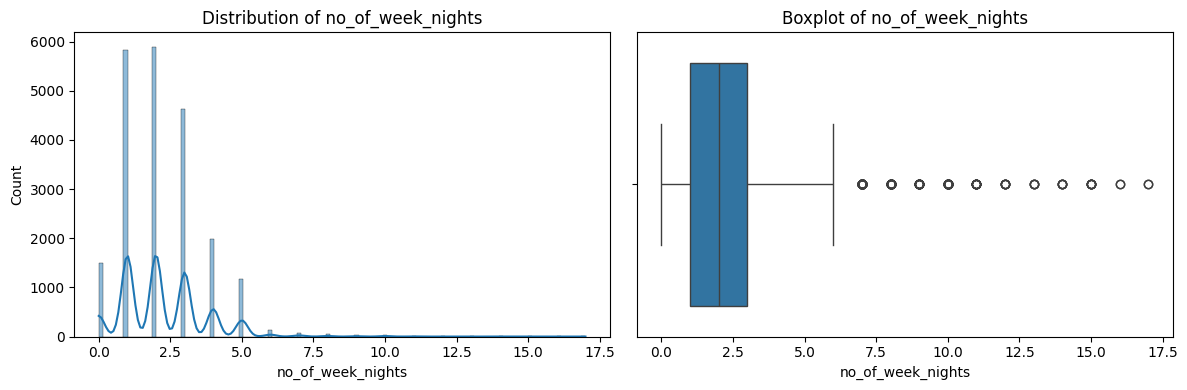

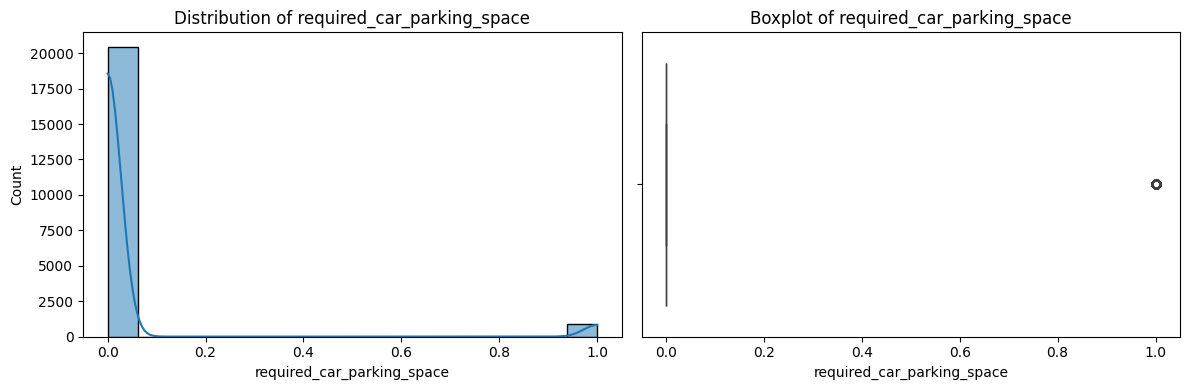

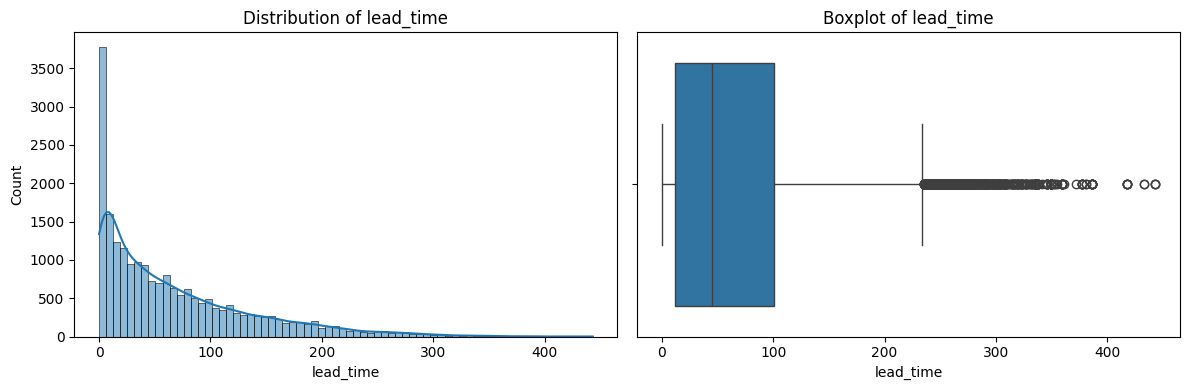

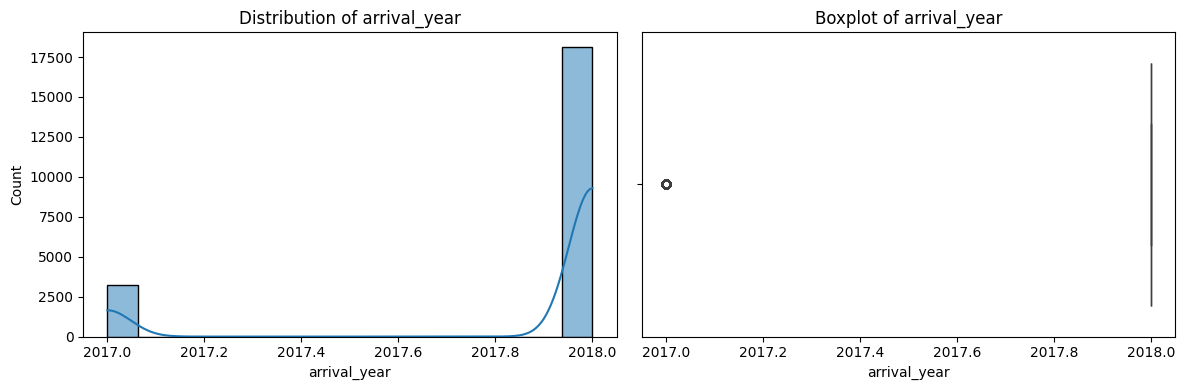

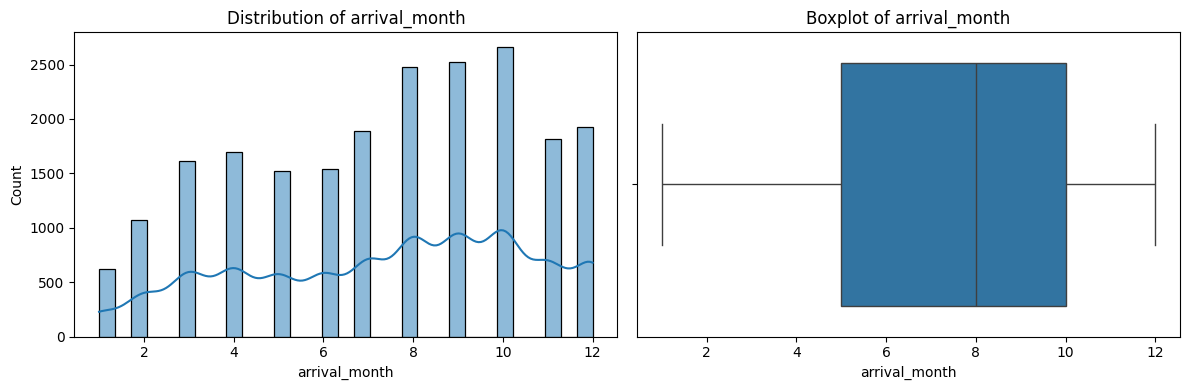

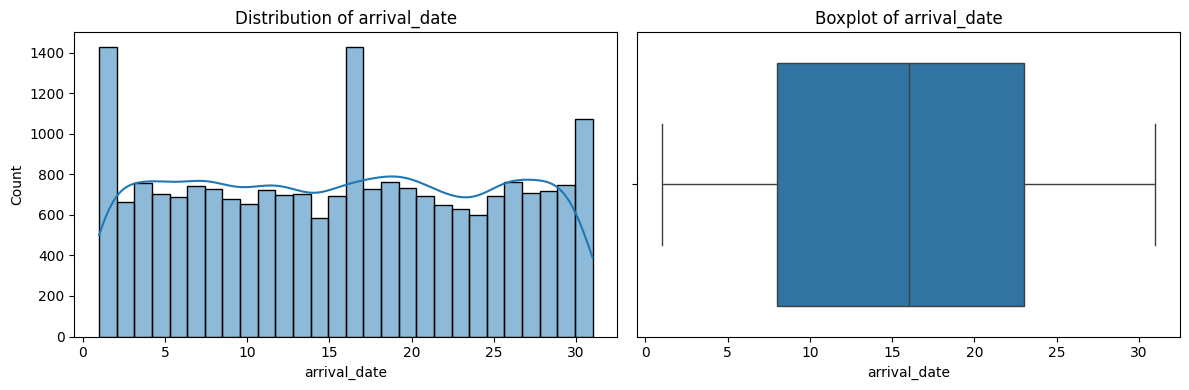

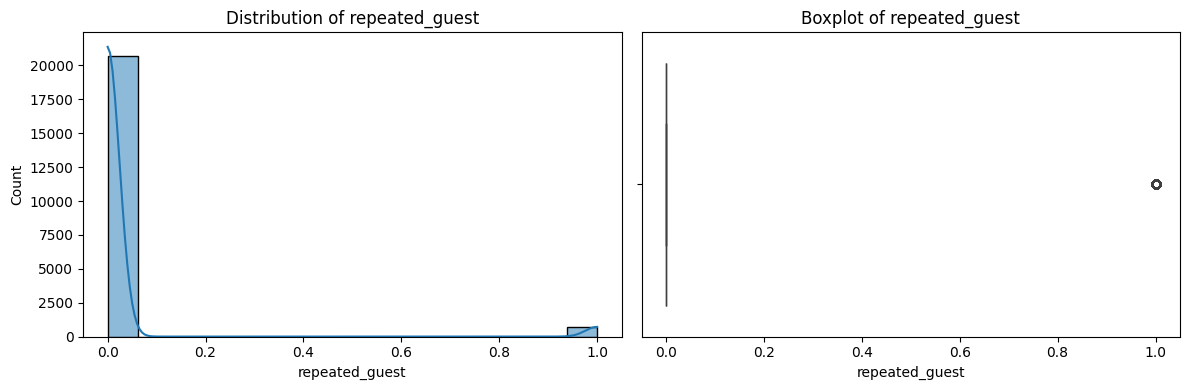

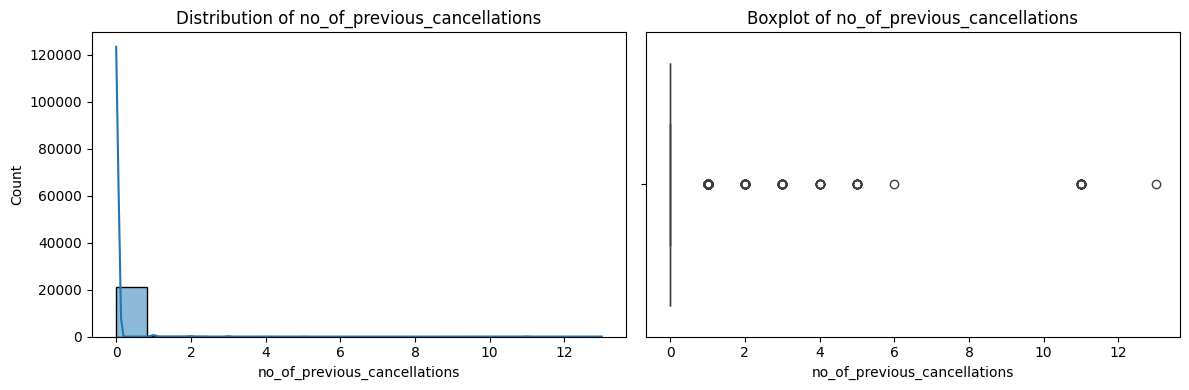

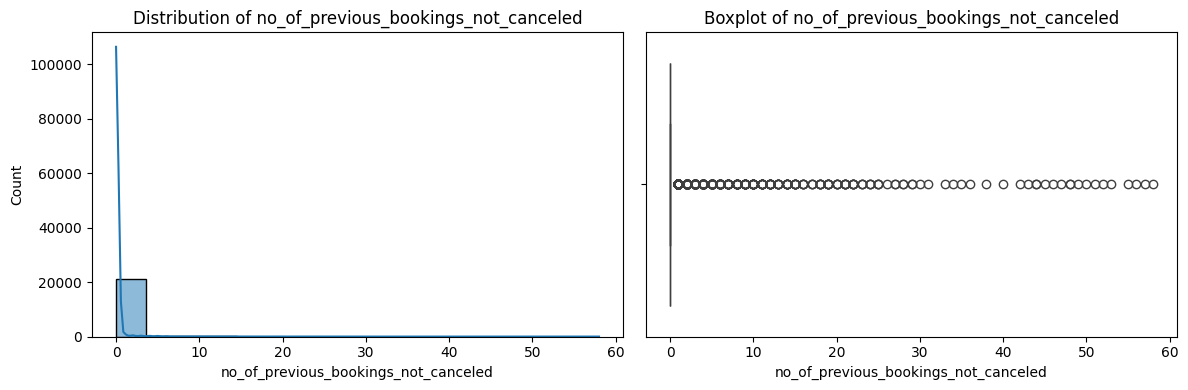

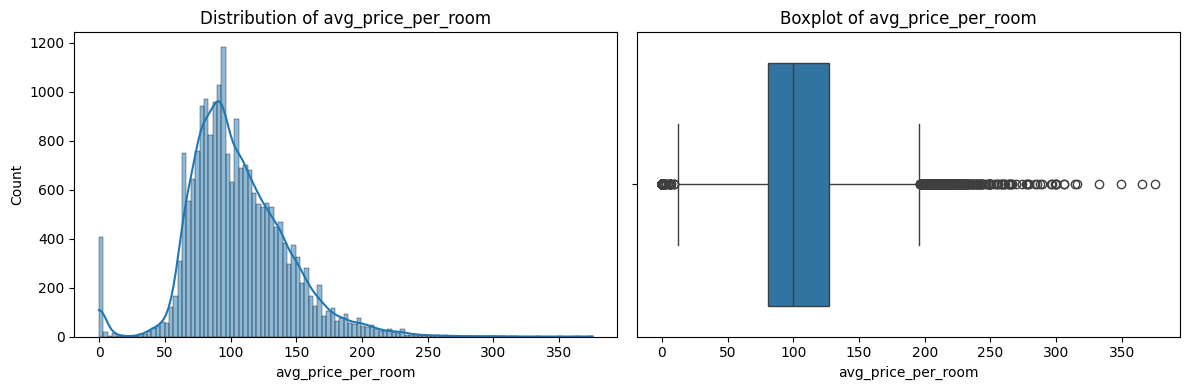

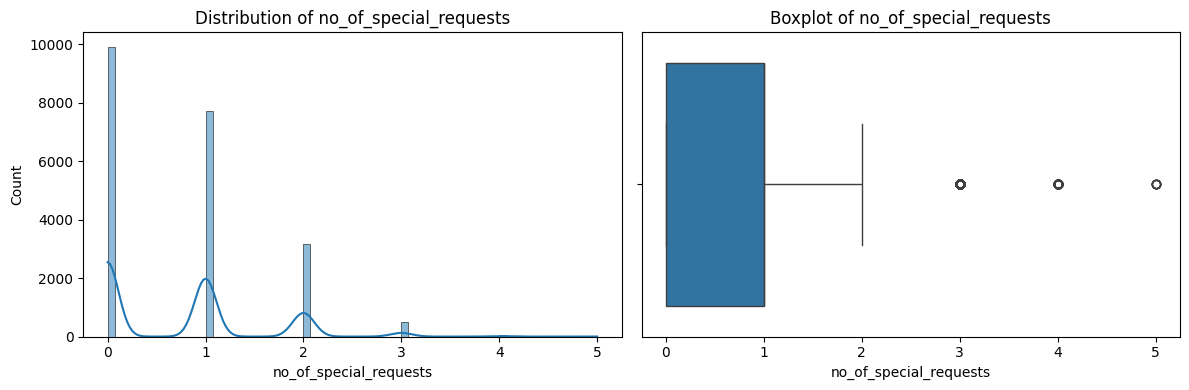

In [216]:
num_plot_dist(df, num_cols.columns)

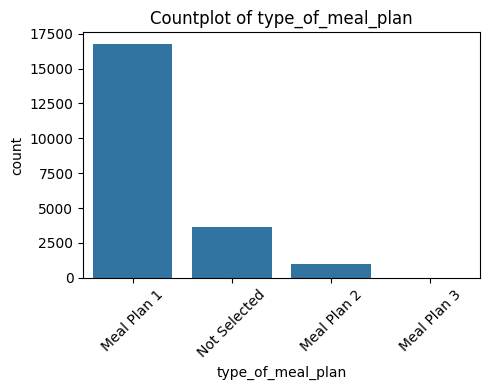

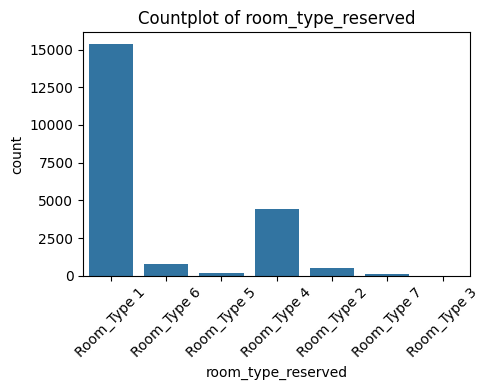

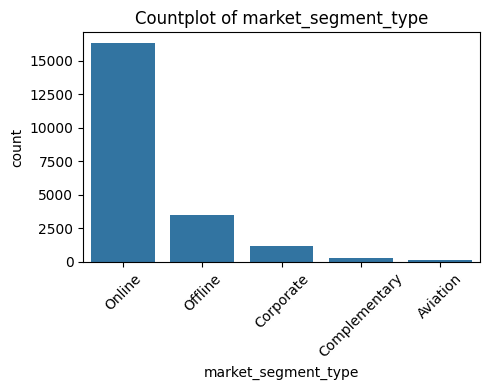

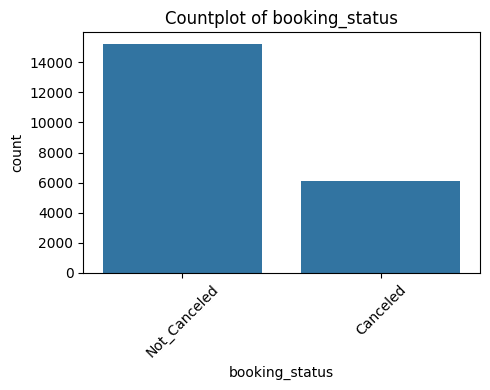

In [217]:
for cat in cat_cols.columns:
    plt.figure(figsize=(5, 4))
    sns.countplot(x=df[cat])
    plt.title(f"Countplot of {cat}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### Bivarient columns

In [218]:
def bivarient_analysis_numeric(df, target, num_cols):
    for col in num_cols:
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        sns.boxplot(x=df[target], y=df[col])
        plt.title(f"Boxplot of {col} vs {target}")
        
        plt.subplot(1, 2, 2)
        sns.violinplot(x=df[target], y=df[col])
        plt.title(f"Violinplot of {col} vs {target}")
        
        plt.tight_layout()
        plt.show()

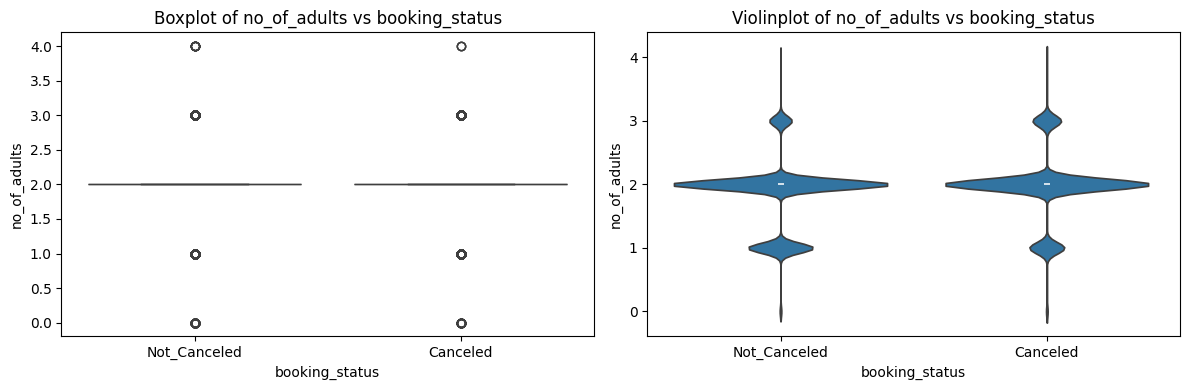

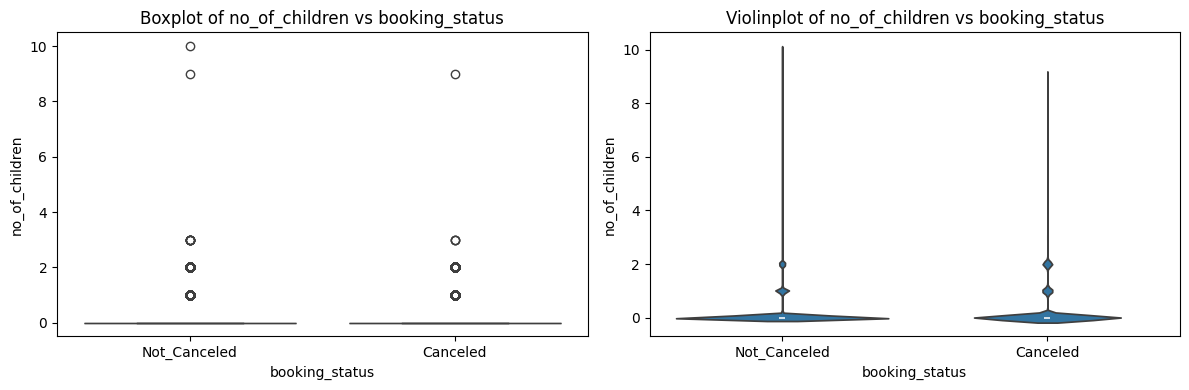

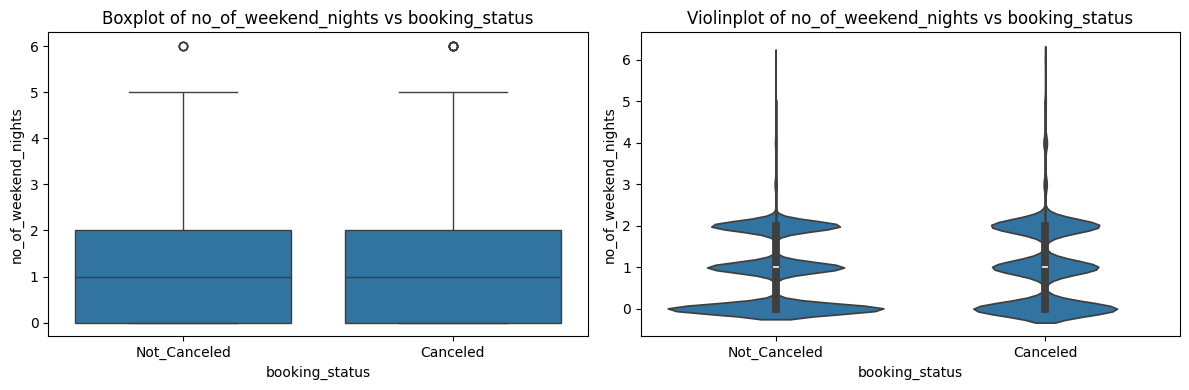

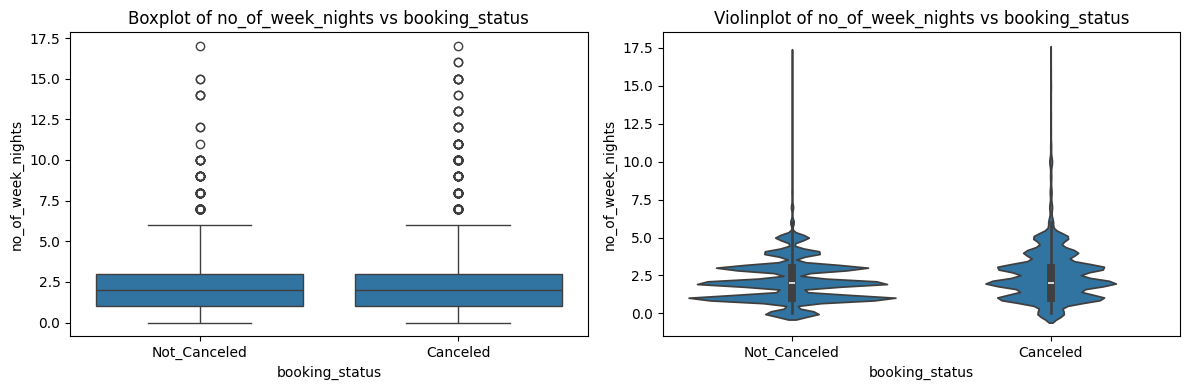

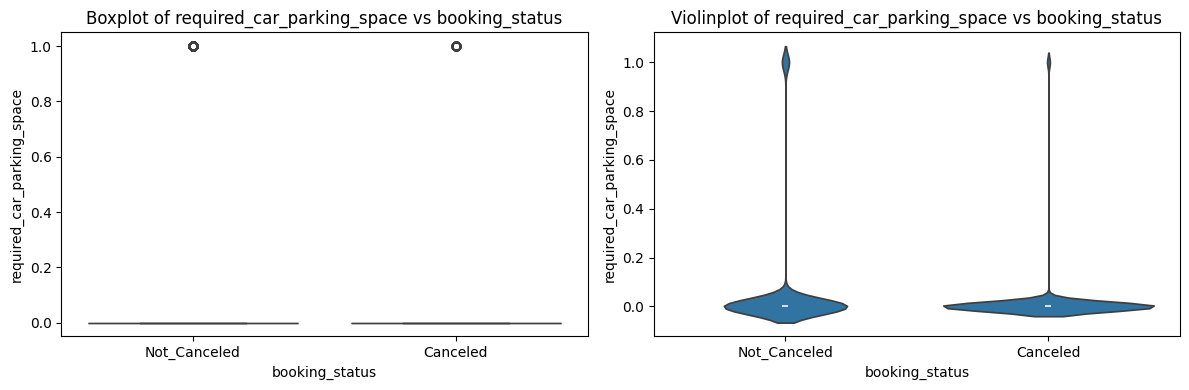

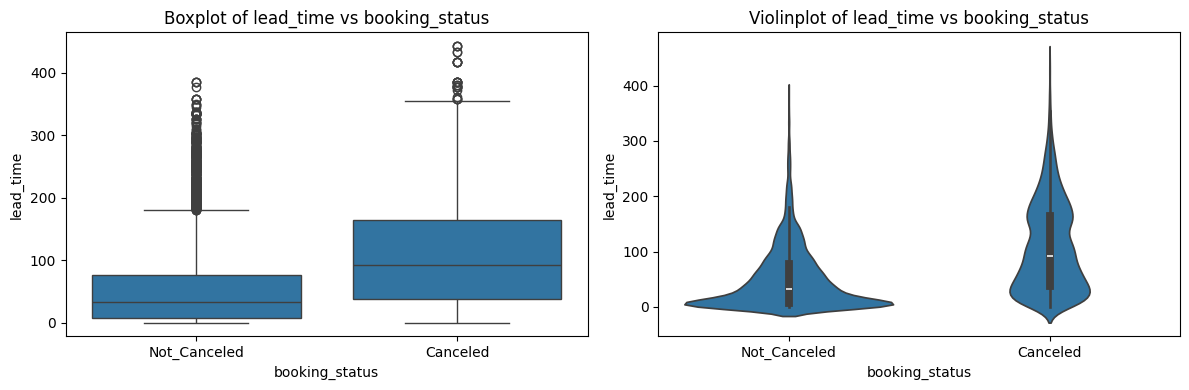

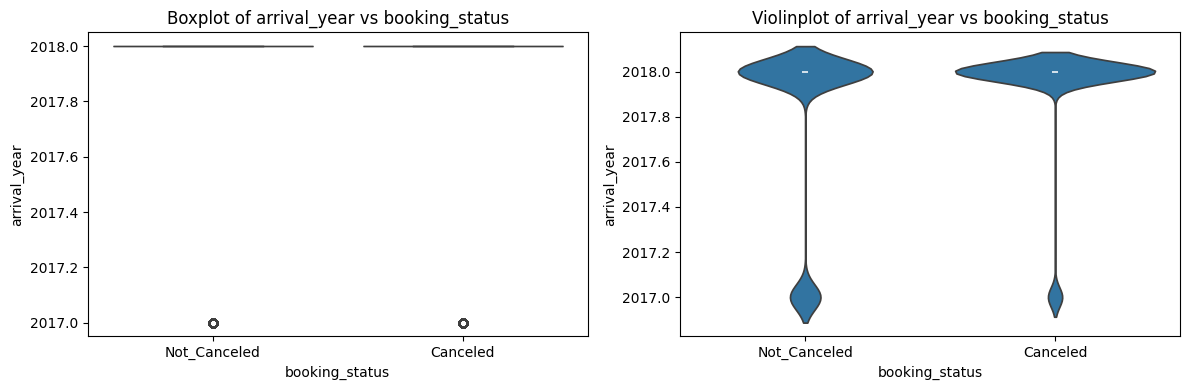

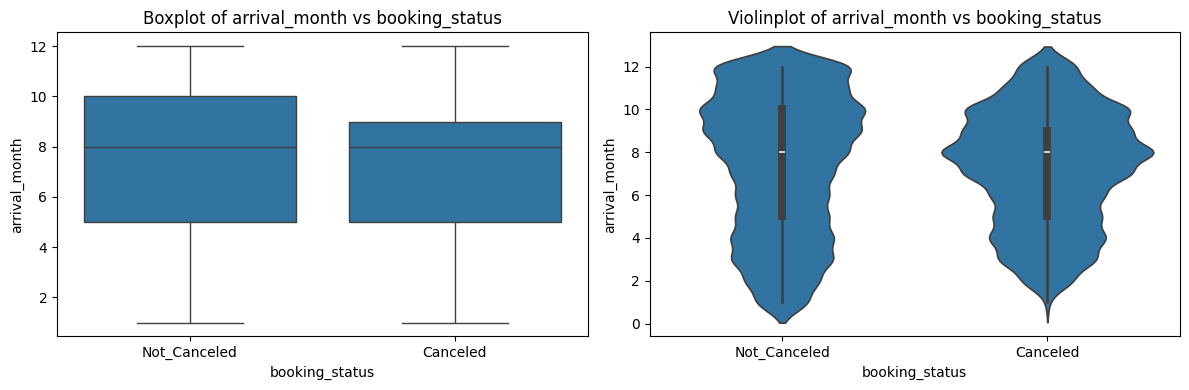

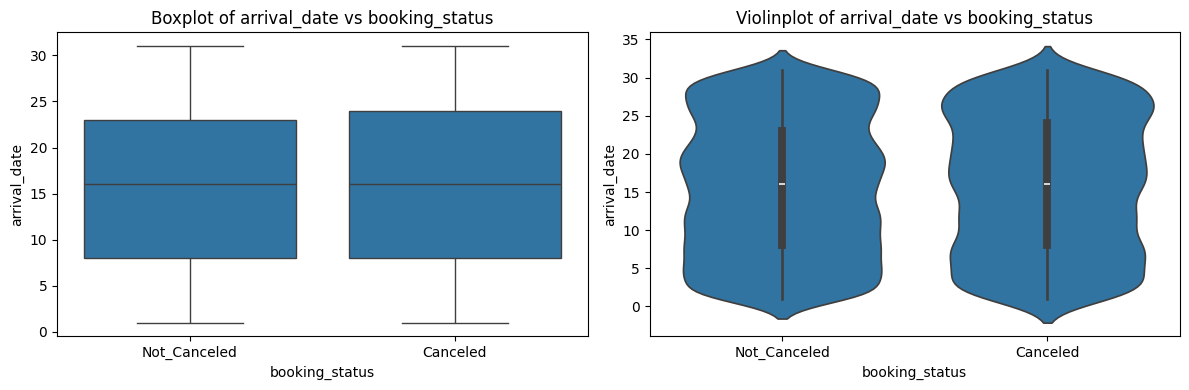

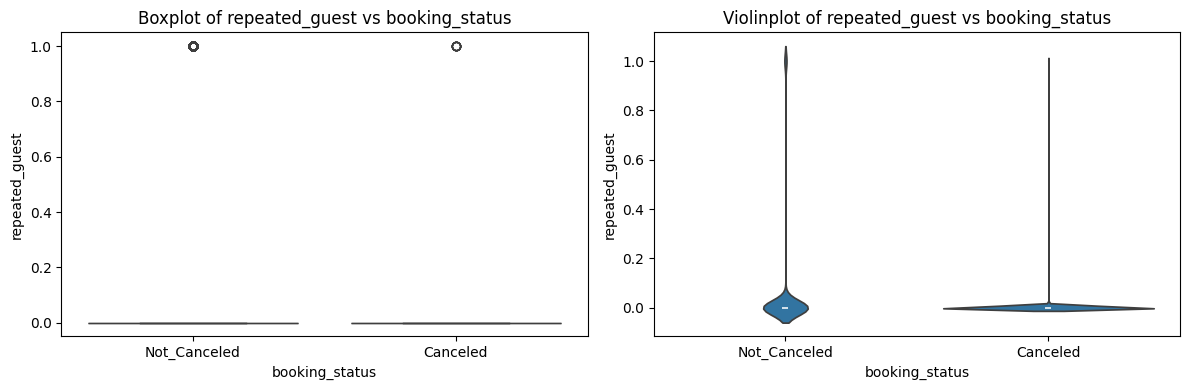

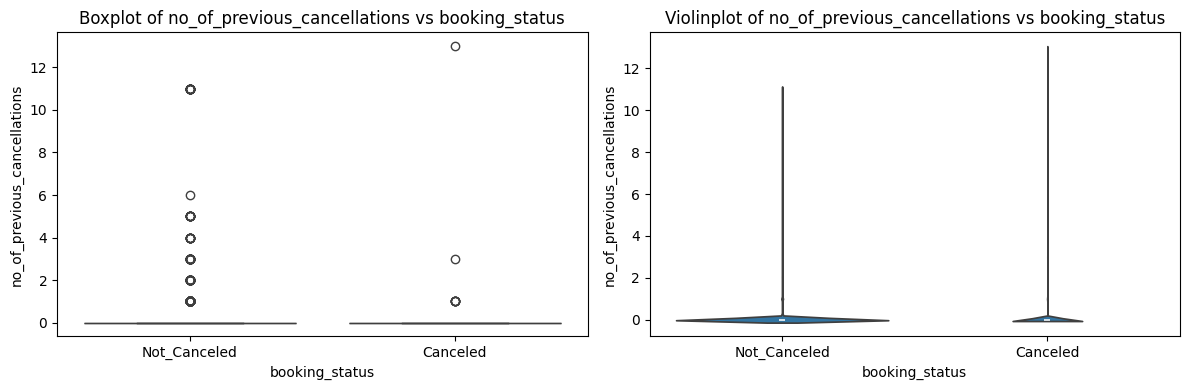

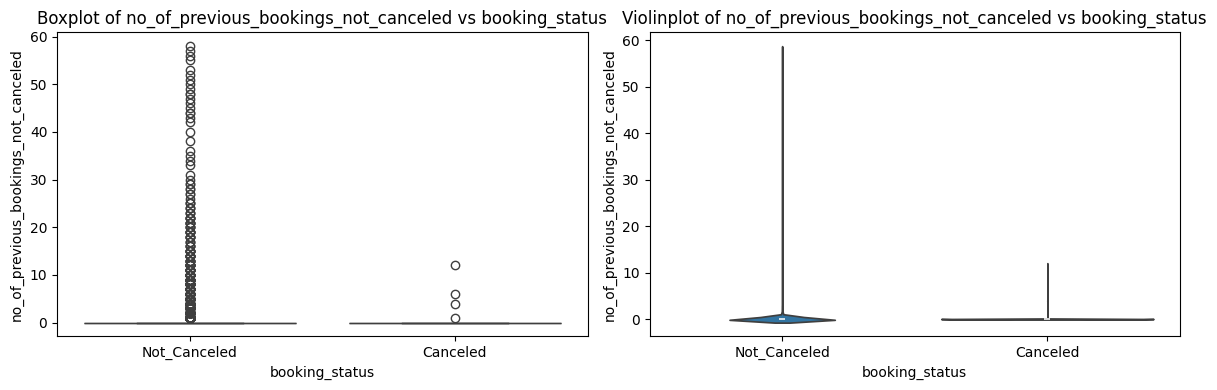

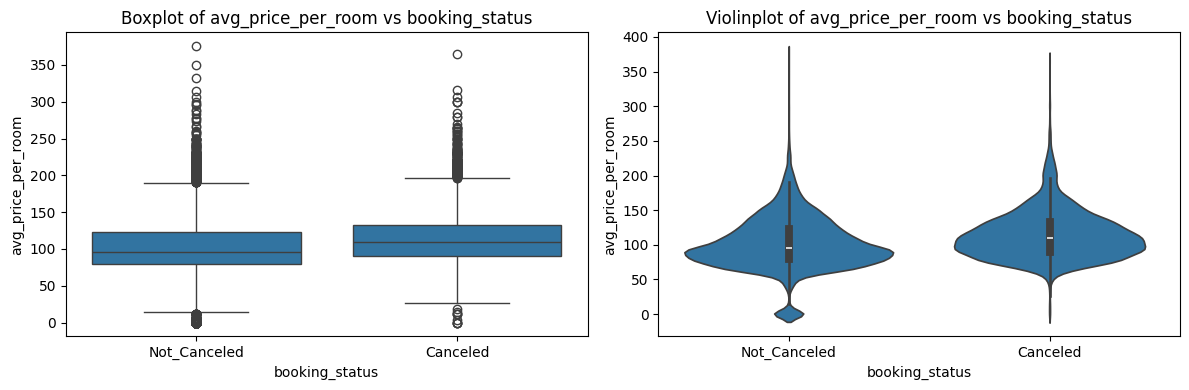

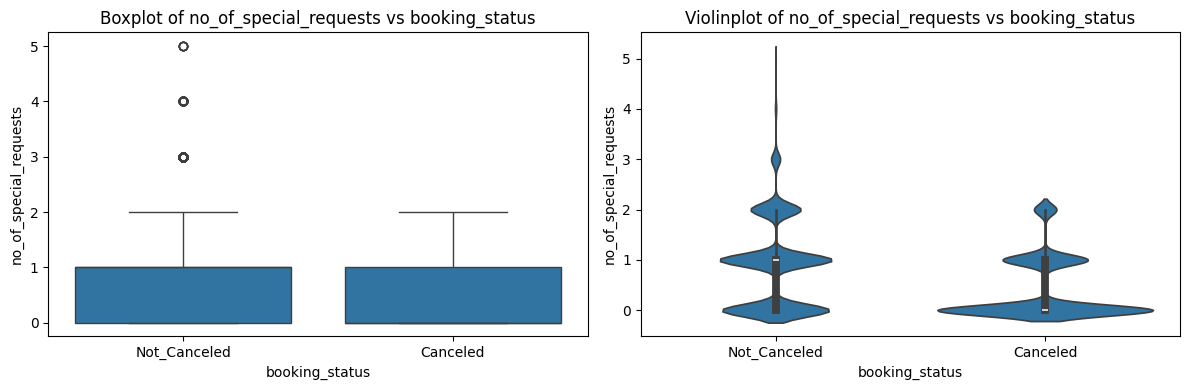

In [219]:
bivarient_analysis_numeric(df, 'booking_status', num_cols.columns)

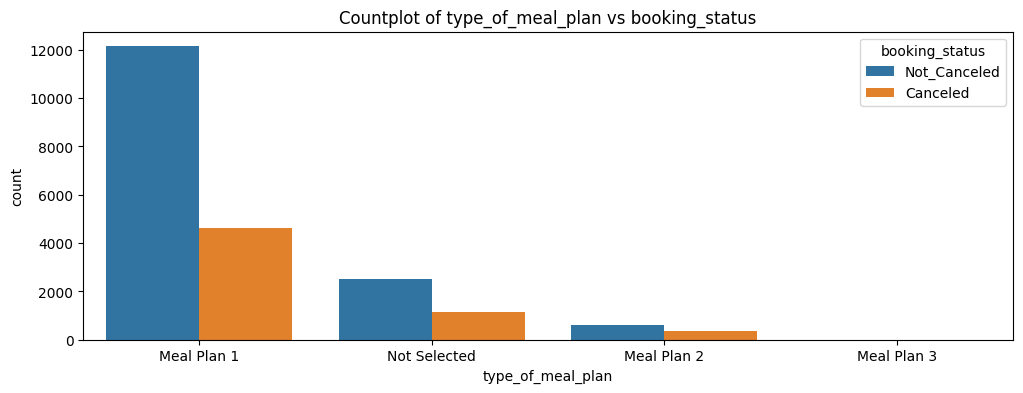

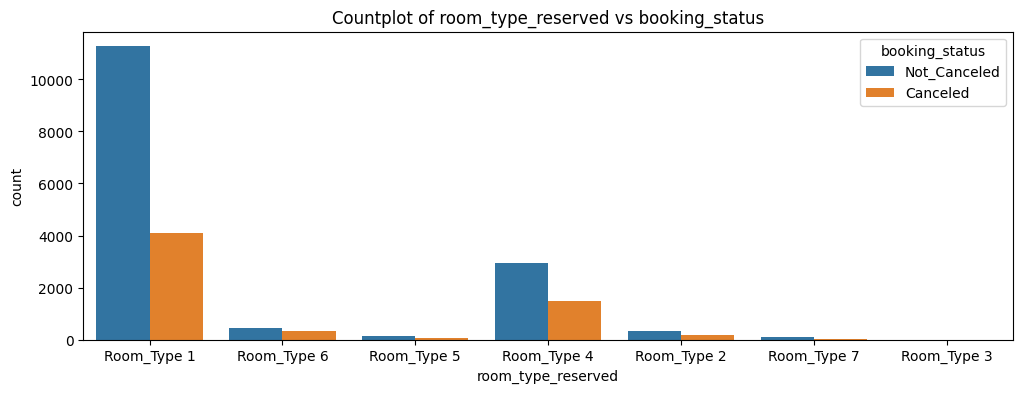

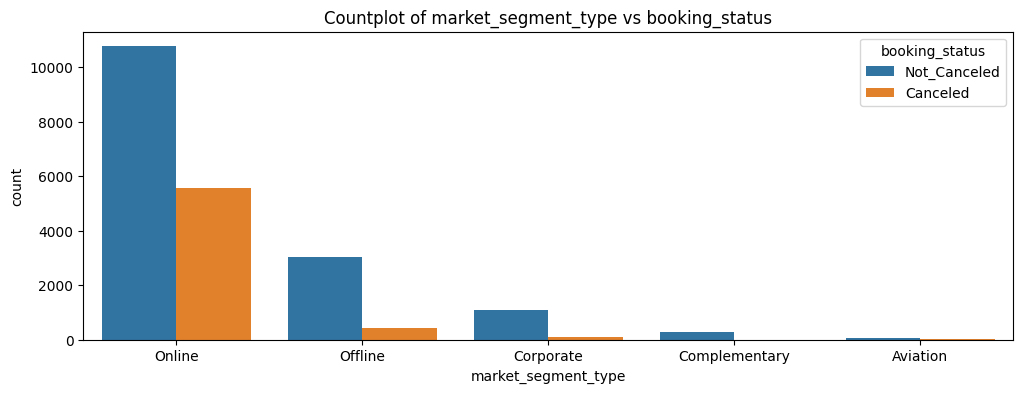

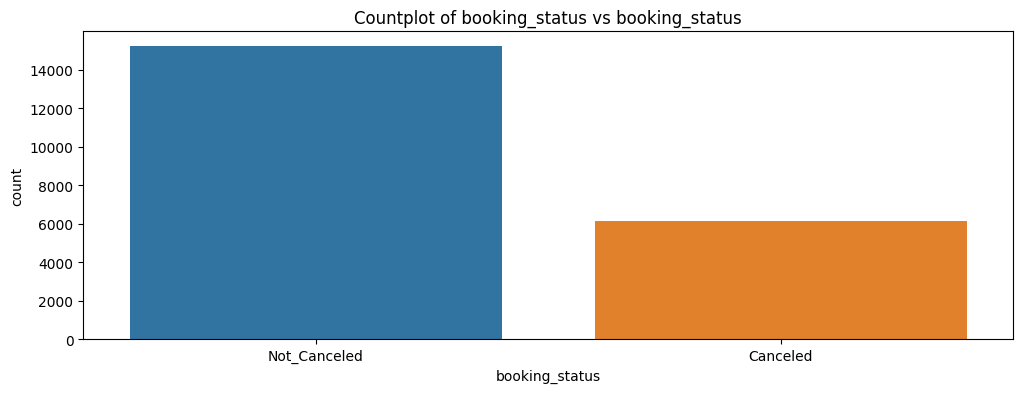

In [220]:
def bivarient_analysis_category(df, target, cat_cols):
    for col in cat_cols:
        plt.figure(figsize=(12, 4))
        sns.countplot(x=df[col], hue=df[target])
        plt.title(f"Countplot of {col} vs {target}")
        plt.show()

bivarient_analysis_category(df, 'booking_status', cat_cols.columns)

### Data prepreocessing

#### Outlier handling

In [221]:
outlier_report = {}
num_cols = df.select_dtypes(include=[np.number]).columns
if len(num_cols) != 0:
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count = len(outliers)
        outlier_pct = (outlier_count / len(df)) * 100

        outlier_report[col] = {
            "OutlierCount": outlier_count,
            "OutlierPct": round(outlier_pct, 2)
        }

pd.DataFrame(outlier_report).T

,OutlierCount,OutlierPct
no_of_adults,5870.0,27.48
no_of_children,2108.0,9.87
no_of_weekend_nights,14.0,0.07
no_of_week_nights,227.0,1.06
required_car_parking_space,907.0,4.25
lead_time,685.0,3.21
arrival_year,3218.0,15.07
arrival_month,0.0,0.00
arrival_date,0.0,0.00
repeated_guest,692.0,3.24


In [222]:
### Handling outlier using IQR capping method
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return series.clip(lower=lower_bound, upper=upper_bound)

columns = ['no_of_adults','no_of_children','no_of_weekend_nights','no_of_week_nights','required_car_parking_space','lead_time','arrival_year','arrival_month','arrival_date','repeated_guest','no_of_previous_cancellations','no_of_previous_bookings_not_canceled','avg_price_per_room','no_of_special_requests']

for col in columns:
    print(f"Addresing outlier: {col}")
    df[col] = cap_outliers(df[col])

Addresing outlier: no_of_adults
Addresing outlier: no_of_children
Addresing outlier: no_of_weekend_nights
Addresing outlier: no_of_week_nights
Addresing outlier: required_car_parking_space
Addresing outlier: lead_time
Addresing outlier: arrival_year
Addresing outlier: arrival_month
Addresing outlier: arrival_date
Addresing outlier: repeated_guest
Addresing outlier: no_of_previous_cancellations
Addresing outlier: no_of_previous_bookings_not_canceled
Addresing outlier: avg_price_per_room
Addresing outlier: no_of_special_requests


#### Skewness handling

In [223]:
skew_report = {}
for col in data.select_dtypes(include=[np.number]):
    mean_val = data[col].mean()
    median_val = data[col].median()
    std_val = data[col].std()
    diff_val = round(abs(mean_val - median_val), 2)

    ratio = 0 if std_val == 0 else round(diff_val/std_val, 2)

    if ratio > 0.3:
         skew_due_to_outlier = "Likely Outlier-Driven"
    else:
        skew_due_to_outlier = "Not Outlier-Driven"

    skew = data[col].dropna().skew()

    if skew > 0:
        direction = "Positive skewed"
    elif skew < 0:
        direction = "Negative skewed"
    else:
        direction = "Roughly Symmetric"

    if abs(skew) < 0.5:
        skew_interpretation = "Fairly Symmetric - No transformation needed"
    elif abs(skew) > 1:
        skew_interpretation = "Moderately Skewed - Consider transformation if critical"
    else:
        skew_interpretation = "Highly Skewed - Transformation Recommended (log/sqrt/BoxCox)"


    skew_report[col] = (round(skew, 2), direction, skew_interpretation, mean_val, median_val, diff_val, ratio, skew_due_to_outlier)

skew_df = pd.DataFrame(skew_report, index=["Skewness","Direction","Skew interpretation","Mean", "Median","Diff Mean-Median","Diff/Std Deviation","Skew Due to Outlier"]).T
skew_df

,Skewness,Direction,Skew interpretation,Mean,Median,Diff Mean-Median,Diff/Std Deviation,Skew Due to Outlier
no_of_adults,-0.31,Negative skewed,Fairly Symmetric - No transformation needed,1.885388,2.0,0.11,0.21,Not Outlier-Driven
no_of_children,4.17,Positive skewed,Moderately Skewed - Consider transformation if...,0.140081,0.0,0.14,0.3,Not Outlier-Driven
no_of_weekend_nights,0.64,Positive skewed,Highly Skewed - Transformation Recommended (lo...,0.875977,1.0,0.12,0.14,Not Outlier-Driven
no_of_week_nights,1.55,Positive skewed,Moderately Skewed - Consider transformation if...,2.252914,2.0,0.25,0.17,Not Outlier-Driven
required_car_parking_space,4.54,Positive skewed,Moderately Skewed - Consider transformation if...,0.042465,0.0,0.04,0.2,Not Outlier-Driven
lead_time,1.41,Positive skewed,Moderately Skewed - Consider transformation if...,67.388501,45.0,22.39,0.32,Likely Outlier-Driven
arrival_year,-1.95,Negative skewed,Moderately Skewed - Consider transformation if...,2017.849338,2018.0,0.15,0.42,Likely Outlier-Driven
arrival_month,-0.29,Negative skewed,Fairly Symmetric - No transformation needed,7.340138,8.0,0.66,0.21,Not Outlier-Driven
arrival_date,0.01,Positive skewed,Fairly Symmetric - No transformation needed,15.754951,16.0,0.25,0.03,Not Outlier-Driven
repeated_guest,5.28,Positive skewed,Moderately Skewed - Consider transformation if...,0.032399,0.0,0.03,0.17,Not Outlier-Driven


In [224]:
from sklearn.preprocessing import PowerTransformer

# Select columns to transform
cols_to_transform = ['no_of_special_requests','avg_price_per_room','no_of_weekend_nights']

print(f"Cols to handle skewness: {cols_to_transform}")
# Initialize Yeo-Johnson transformer
pt = PowerTransformer(method='yeo-johnson', standardize=False)

for col in cols_to_transform:
    # Fit and transform the column (Yeo-Johnson handles negatives)
    df[col] = pt.fit_transform(df[[col]])


Cols to handle skewness: ['no_of_special_requests', 'avg_price_per_room', 'no_of_weekend_nights']


In [225]:
for cat in cat_cols:
    print(f"*********{cat}*********")
    print(df[cat].value_counts())

*********type_of_meal_plan*********
type_of_meal_plan
Meal Plan 1     16759
Not Selected     3627
Meal Plan 2       969
Meal Plan 3         4
Name: count, dtype: int64
*********room_type_reserved*********
room_type_reserved
Room_Type 1    15375
Room_Type 4     4403
Room_Type 6      758
Room_Type 2      500
Room_Type 5      190
Room_Type 7      129
Room_Type 3        4
Name: count, dtype: int64
*********market_segment_type*********
market_segment_type
Online           16324
Offline           3471
Corporate         1192
Complementary      291
Aviation            81
Name: count, dtype: int64
*********booking_status*********
booking_status
Not_Canceled    15231
Canceled         6128
Name: count, dtype: int64


In [226]:
from sklearn.preprocessing import OneHotEncoder

ohe_columns = ['type_of_meal_plan', 'room_type_reserved','market_segment_type']
ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
ohe_encode = ohe.fit_transform(df[ohe_columns])

ohe_df = pd.DataFrame(ohe_encode, columns=ohe.get_feature_names_out(ohe_columns))
new_df = pd.concat([df.drop(columns=ohe_columns).reset_index(drop=True), ohe_df], axis=1)

new_df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2,0,1.012032,1,0,26.0,2018,10,17,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,0,0.657985,1,0,98.0,2018,7,16,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2,0,-0.000000,3,0,234.5,2018,9,8,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2,0,1.012032,5,0,195.0,2018,8,8,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2,0,-0.000000,2,0,188.0,2018,6,15,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [227]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
new_df['booking_status'] = le.fit_transform(new_df['booking_status'])
new_df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2,0,1.012032,1,0,26.0,2018,10,17,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,0,0.657985,1,0,98.0,2018,7,16,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2,0,-0.000000,3,0,234.5,2018,9,8,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2,0,1.012032,5,0,195.0,2018,8,8,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2,0,-0.000000,2,0,188.0,2018,6,15,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [228]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21359 entries, 0 to 21358
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          21359 non-null  int64  
 1   no_of_children                        21359 non-null  int64  
 2   no_of_weekend_nights                  21359 non-null  float64
 3   no_of_week_nights                     21359 non-null  int64  
 4   required_car_parking_space            21359 non-null  int64  
 5   lead_time                             21359 non-null  float64
 6   arrival_year                          21359 non-null  int64  
 7   arrival_month                         21359 non-null  int64  
 8   arrival_date                          21359 non-null  int64  
 9   repeated_guest                        21359 non-null  int64  
 10  no_of_previous_cancellations          21359 non-null  int64  
 11  no_of_previous_

#### Multi collinarity check

<Axes: >

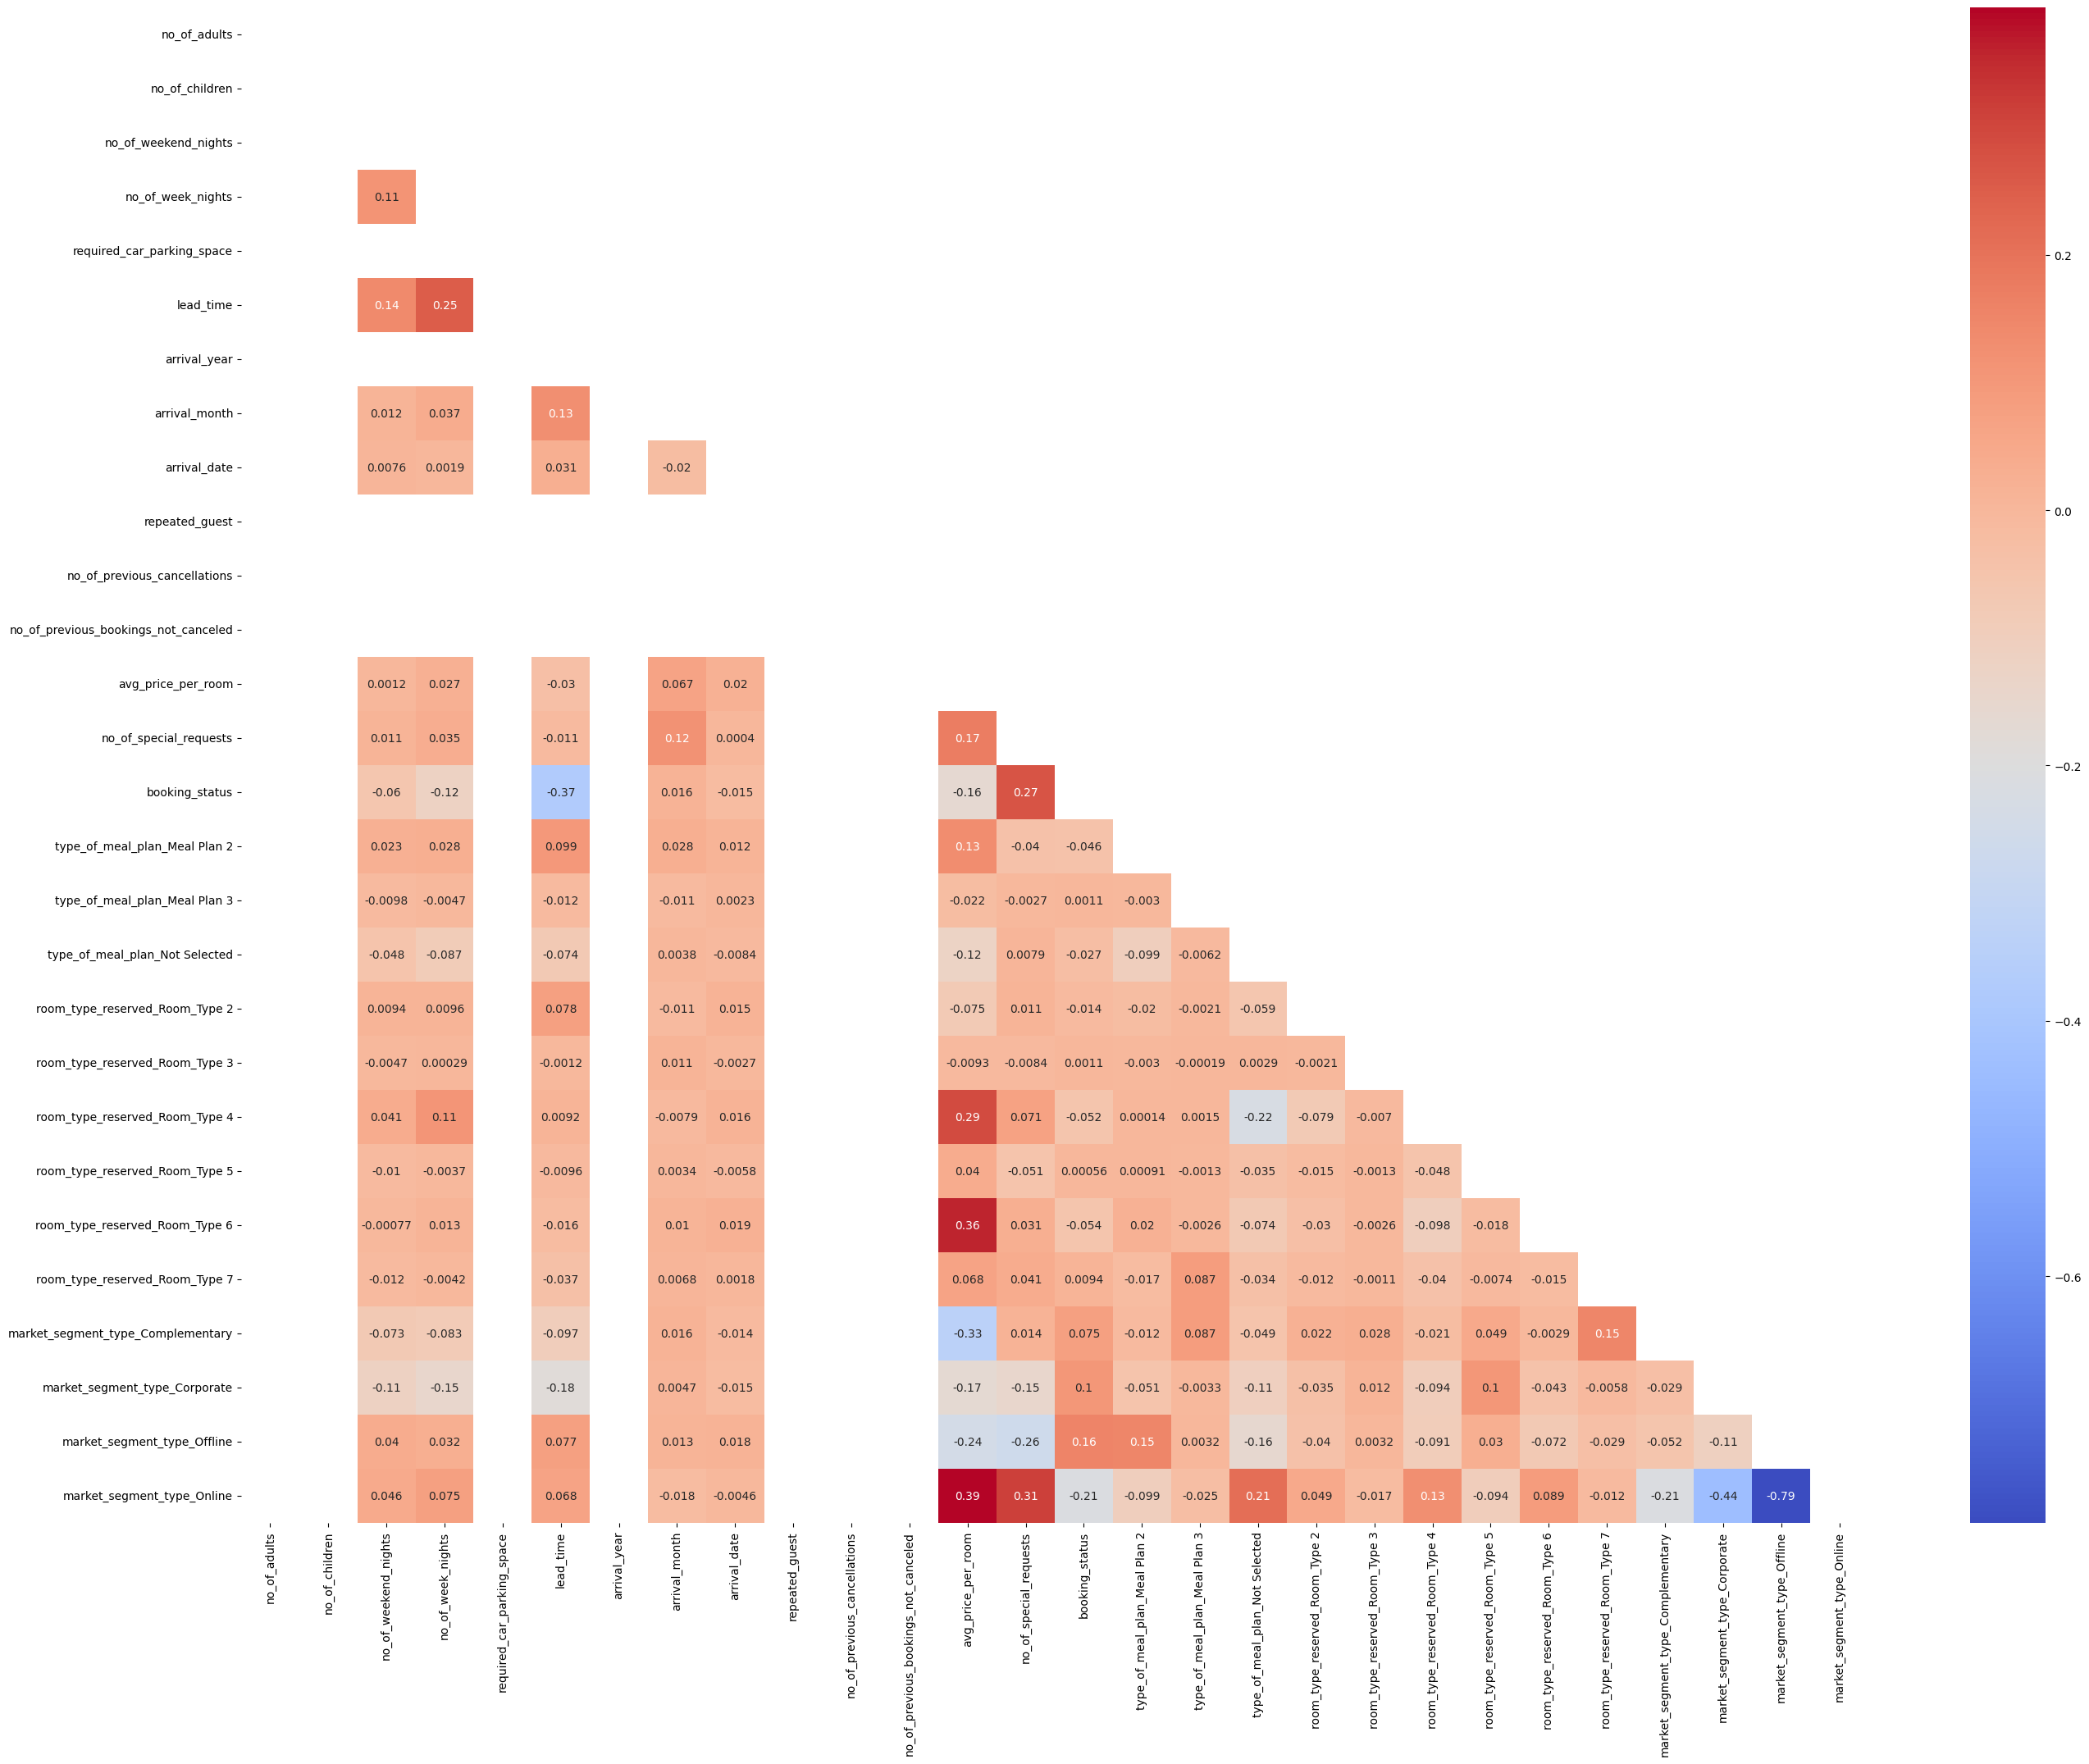

In [229]:
plt.figure(figsize=(32, 24))
sns.heatmap(new_df.corr(), annot=True, cmap='coolwarm', mask=np.triu(new_df.corr()))

In [230]:
new_df.isnull().sum()

no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
required_car_parking_space              0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
type_of_meal_plan_Meal Plan 2           0
type_of_meal_plan_Meal Plan 3           0
type_of_meal_plan_Not Selected          0
room_type_reserved_Room_Type 2          0
room_type_reserved_Room_Type 3          0
room_type_reserved_Room_Type 4          0
room_type_reserved_Room_Type 5          0
room_type_reserved_Room_Type 6          0
room_type_reserved_Room_Type 7    

In [231]:
X = new_df.drop(columns=['booking_status'])
zero_var_cols = X.columns[X.nunique() <= 1].tolist()
print("Columns with zero/constant variance (will be dropped before VIF):", zero_var_cols)

Columns with zero/constant variance (will be dropped before VIF): ['no_of_adults', 'no_of_children', 'required_car_parking_space', 'arrival_year', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled']


In [235]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Drop booking_status (target) and any zero/constant variance columns before VIF
# Zero variance cols cause divide-by-zero → NaN VIF values
X = new_df.drop(columns=['booking_status'])
zero_var_cols = X.columns[X.nunique() <= 1].tolist()
X_vif = X.drop(columns=zero_var_cols)

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

print(f"Dropped zero-variance cols before VIF: {zero_var_cols}")
print("VIF > 10 indicates high multicollinearity — consider dropping those features")
vif_data

Dropped zero-variance cols before VIF: ['no_of_adults', 'no_of_children', 'required_car_parking_space', 'arrival_year', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled']
VIF > 10 indicates high multicollinearity — consider dropping those features


,feature,VIF
0,avg_price_per_room,10.333927
1,arrival_month,6.417774
2,arrival_date,3.855910
3,no_of_week_nights,3.756695
4,lead_time,2.338228
5,no_of_special_requests,2.338074
6,no_of_weekend_nights,2.195742
7,room_type_reserved_Room_Type 4,1.582451
8,market_segment_type_Offline,1.374615
9,type_of_meal_plan_Not Selected,1.340159


In [234]:
new_df = new_df.drop(columns=['market_segment_type_Online'], axis=1)

<Axes: >

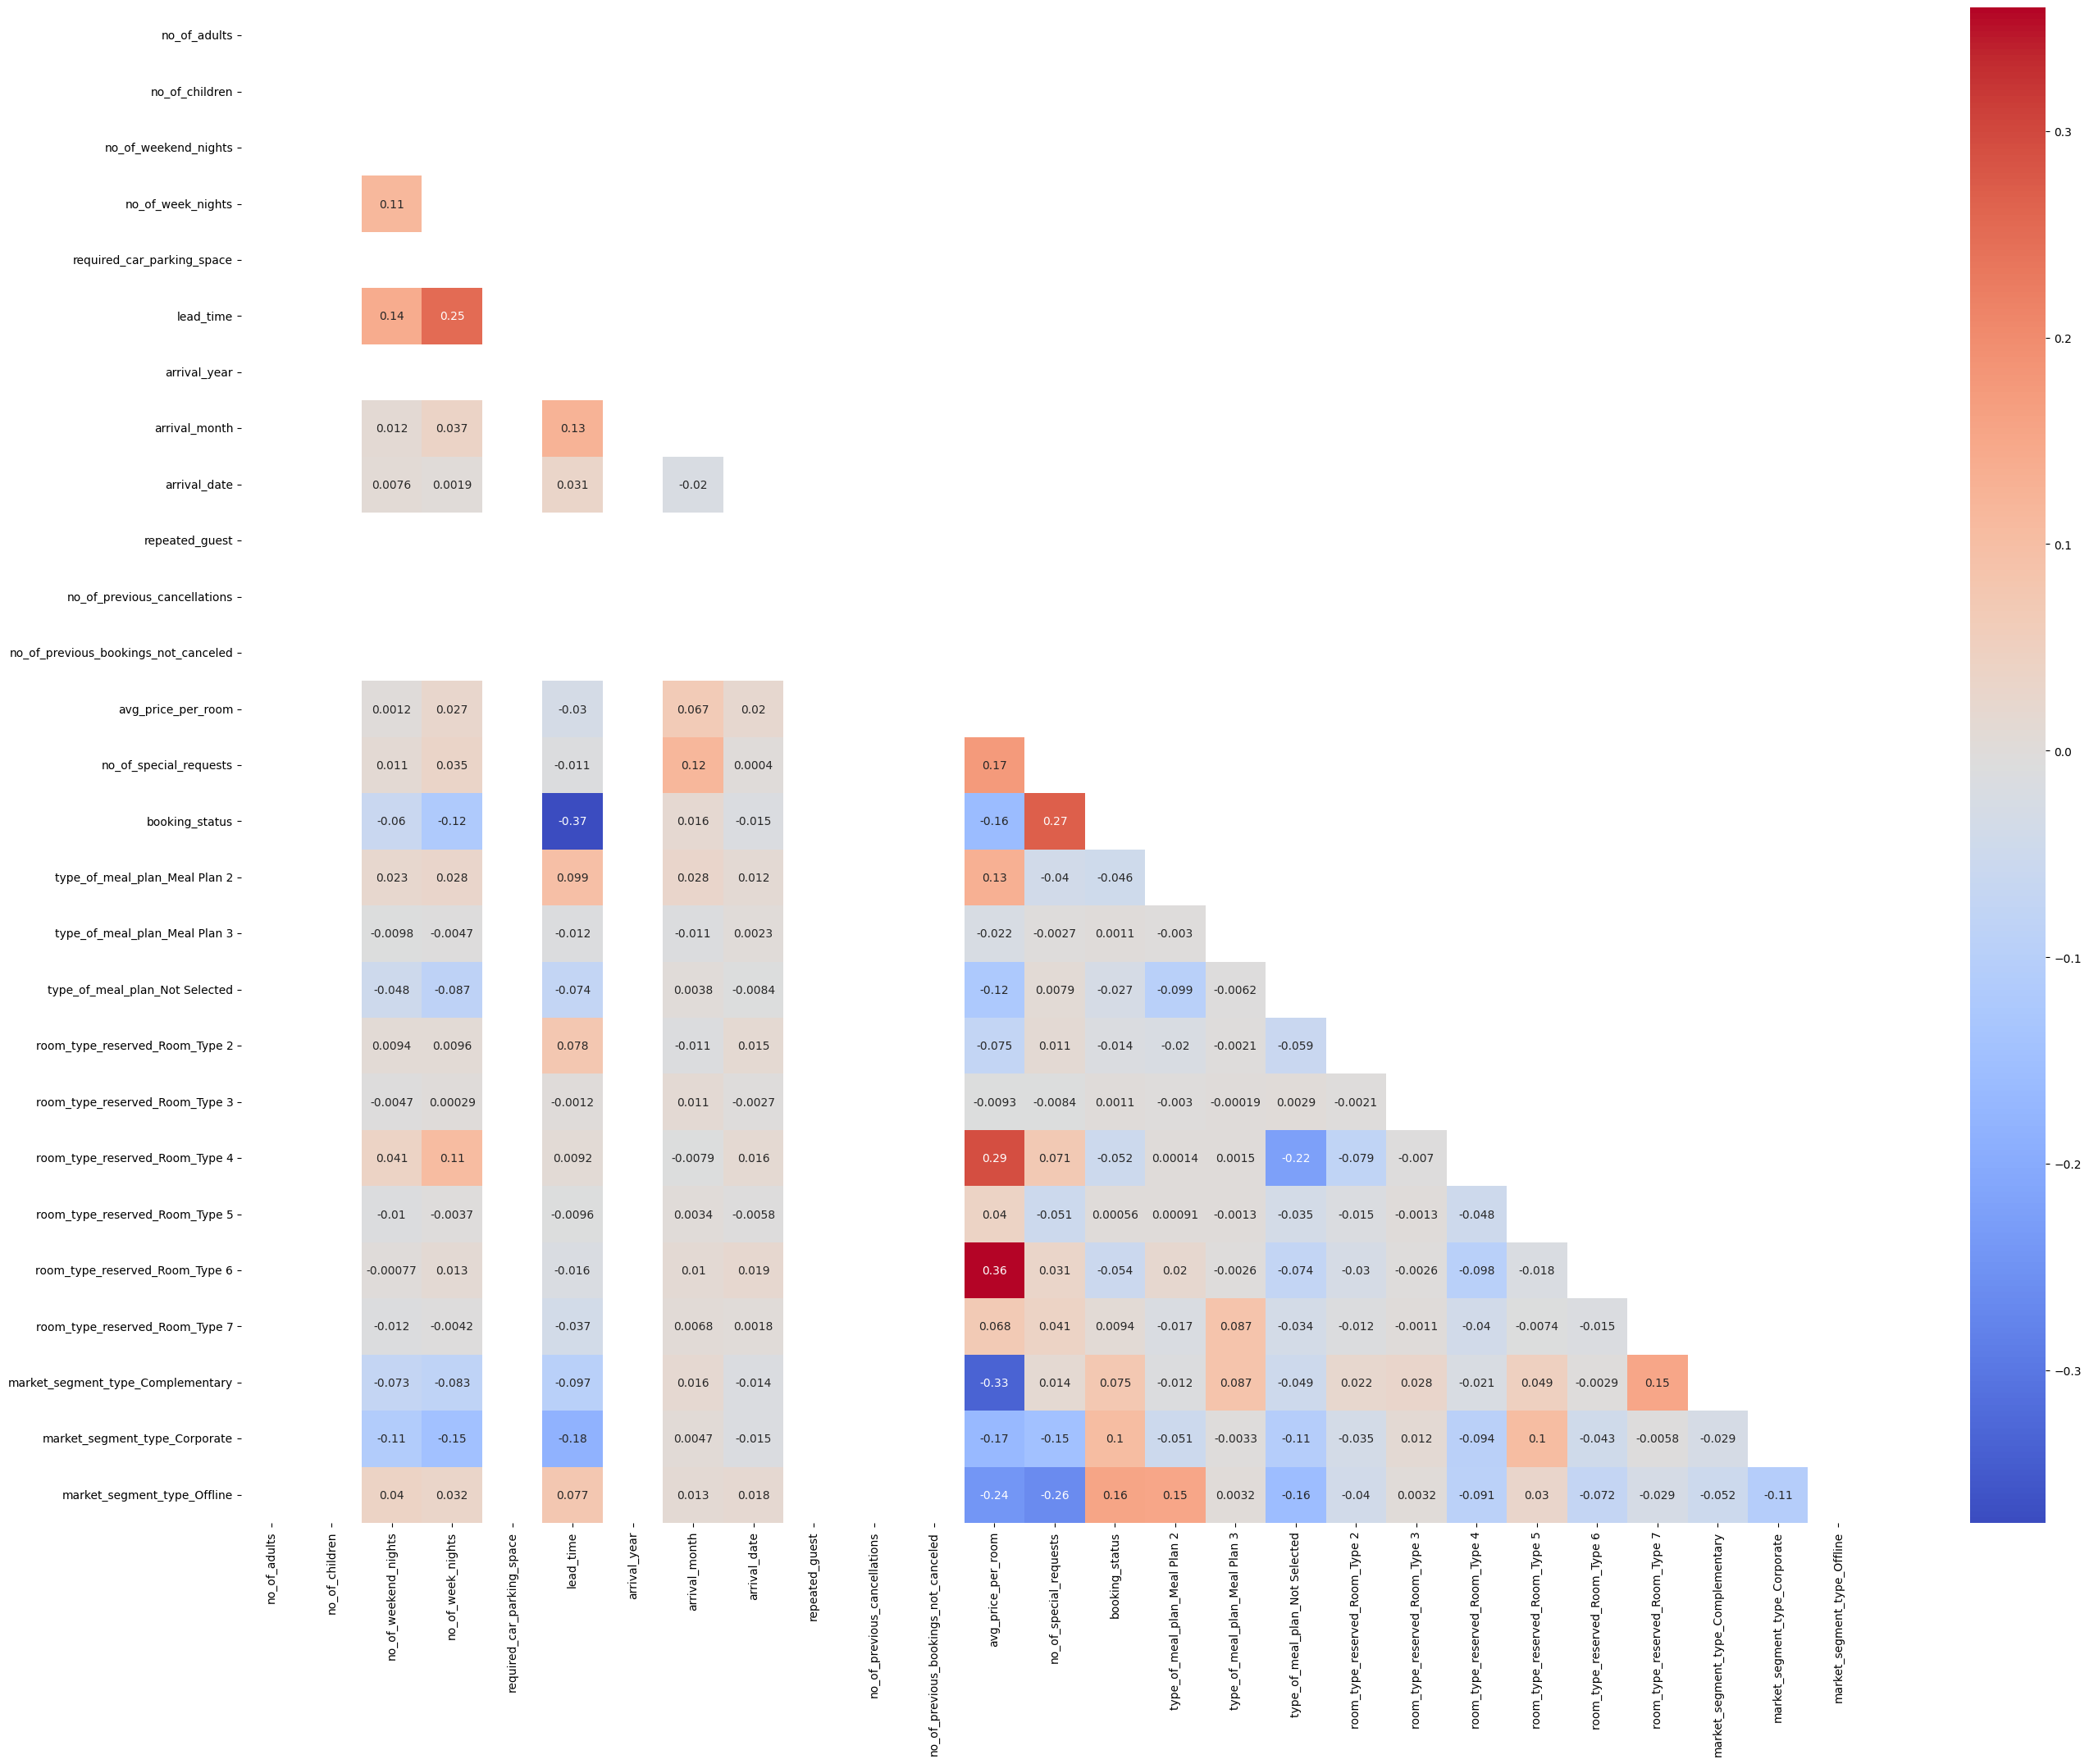

In [236]:
plt.figure(figsize=(32, 24))
sns.heatmap(new_df.corr(), annot=True, cmap='coolwarm', mask=np.triu(new_df.corr()))

### Building the model

#### Divide the independent and dependent features

In [237]:
X = new_df.drop(columns=['booking_status'])
y = new_df['booking_status']

#### Split the train and test data

In [238]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### Treat imbalanced target column 

In [239]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_res, y_train_res  = smote.fit_resample(X_train, y_train)

print(X_train_res.shape, y_train_res.shape)
#Check balance after resampling
print("Class distribution before SMOTE:\n", y_train.value_counts(normalize=True))
print("Class distribution after SMOTE:\n", pd.Series(y_train_res).value_counts(normalize=True))

(24370, 26) (24370,)
Class distribution before SMOTE:
 booking_status
1    0.713115
0    0.286885
Name: proportion, dtype: float64
Class distribution after SMOTE:
 booking_status
1    0.5
0    0.5
Name: proportion, dtype: float64


#### Feature selection

In [240]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train_res, y_train_res)

RandomForestClassifier(random_state=42)

In [242]:
feature_importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train_res.columns,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

feature_importance_df

,Feature,Importance
5,lead_time,0.243955
13,no_of_special_requests,0.207967
12,avg_price_per_room,0.137083
8,arrival_date,0.073877
2,no_of_weekend_nights,0.070367
7,arrival_month,0.070321
25,market_segment_type_Offline,0.067571
3,no_of_week_nights,0.039086
19,room_type_reserved_Room_Type 4,0.027668
16,type_of_meal_plan_Not Selected,0.027629


#### Top 10 feature selection

In [248]:
top_features = feature_importance_df.head(15)['Feature'].tolist()
top_features

['lead_time',
 'no_of_special_requests',
 'avg_price_per_room',
 'arrival_date',
 'no_of_weekend_nights',
 'arrival_month',
 'market_segment_type_Offline',
 'no_of_week_nights',
 'room_type_reserved_Room_Type 4',
 'type_of_meal_plan_Not Selected',
 'market_segment_type_Corporate',
 'type_of_meal_plan_Meal Plan 2',
 'room_type_reserved_Room_Type 6',
 'room_type_reserved_Room_Type 2',
 'market_segment_type_Complementary']

In [249]:
top_feature_df = new_df[top_features + ['booking_status']]
top_feature_df.head()

,lead_time,no_of_special_requests,avg_price_per_room,arrival_date,no_of_weekend_nights,arrival_month,market_segment_type_Offline,no_of_week_nights,room_type_reserved_Room_Type 4,type_of_meal_plan_Not Selected,market_segment_type_Corporate,type_of_meal_plan_Meal Plan 2,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 2,market_segment_type_Complementary,booking_status
0,26.0,-0.000000,86.597366,17,1.012032,10,0.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,98.0,0.873369,68.096684,16,0.657985,7,0.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,234.5,-0.000000,42.469087,8,-0.000000,9,1.0,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,195.0,-0.000000,43.637755,8,1.012032,8,1.0,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,188.0,-0.000000,72.146615,15,-0.000000,6,1.0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


#### Feature scaling

In [254]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_res),index=X_train_res.index, columns=X_train_res.columns)
X_test_scaled =  pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)

#### Build model

In [257]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, BaggingClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, StackingClassifier, VotingClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier


def assess_overfitting(row, cv):
    """Assess relative overfitting risk using train/test F1 and CV scores."""
    train_f1 = row["Train F1"]
    test_f1 = row["Test F1"]

    cv_mean = row[f"CV F1 Mean ({cv}-fold)"]
    cv_std = row[f"CV F1 Std ({cv}-fold)"]

    # Relative gap
    rel_gap = (train_f1 - test_f1) / train_f1

    # Check CV agreement
    cv_agreement = abs(test_f1 - cv_mean) <= cv_std

    if rel_gap > 0.15 and not cv_agreement:
        return "High"
    elif rel_gap > 0.1:
        return "Medium"
    else:
        return "Low"

def plot_roc_curves(model, X_tr, y_tr, X_te, y_te, n_classes, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"{name} - ROC Curves", fontsize=14)

    if n_classes == 2:
        # Binary ROC (normal case)
        RocCurveDisplay.from_estimator(model, X_tr, y_tr, ax=axes[0], name="Train")
        axes[0].set_title("ROC Curve (Train)")

        RocCurveDisplay.from_estimator(model, X_te, y_te, ax=axes[1], name="Test")
        axes[1].set_title("ROC Curve (Test)")

    else:
        # Multiclass OvR ROC
        y_train_bin = label_binarize(y_tr, classes=np.unique(y_tr))
        y_test_bin = label_binarize(y_te, classes=np.unique(y_te))

        y_train_proba = model.predict_proba(X_tr)
        y_test_proba = model.predict_proba(X_te)

        for i, cls in enumerate(np.unique(y_tr)):
            RocCurveDisplay.from_predictions(
                y_train_bin[:, i], y_train_proba[:, i],
                name=f"Class {cls}", ax=axes[0]
            )
        axes[0].set_title("ROC Curve (Train)")

        for i, cls in enumerate(np.unique(y_te)):
            RocCurveDisplay.from_predictions(
                y_test_bin[:, i], y_test_proba[:, i],
                name=f"Class {cls}", ax=axes[1]
            )
        axes[1].set_title("ROC Curve (Test)")

    plt.tight_layout()
    plt.show()


def evaluate_models(X_train, X_test, y_train, y_test,
                    X_scaled_train, X_scaled_test,
                    cv,
                    tune_hyperparameters=False,
                    ranking_metric="Test F1"):
    """
    Evaluate multiple ML models (binary or multiclass).
    """

    results = []
    feature_names = X_train.columns

    # Models that REQUIRE scaling
    models_scaled = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "KNN": KNeighborsClassifier(),
        "SVM": SVC(probability=True),
    }

    # Models that DO NOT require scaling
    models_unscaled = {
        "Decision Tree-Gini": DecisionTreeClassifier(),
        "Decision Tree-Entropy": DecisionTreeClassifier(criterion='entropy'),
        "Random Forest": RandomForestClassifier(),
        "XGBoost": XGBClassifier(eval_metric="logloss"),
        "Naive Bayes": GaussianNB(),
        "Bagging": BaggingClassifier(),
        "AdaBoost": AdaBoostClassifier(),
        "Gradient Boosting": GradientBoostingClassifier(),
    }

    # Hyperparameter grids
    # Hyperparameter grids (tuned to reduce overfitting)
    param_grids = {
        "Logistic Regression": {
            "C": [0.01, 0.1, 1, 5],
            "penalty": ["l2"],
            "solver": ["lbfgs", "saga"],
            "max_iter": [2000]
        },
        "KNN": {
            "n_neighbors": [5, 7, 9, 11],     # avoid too small k
            "weights": ["uniform", "distance"]
        },
        "SVM": {
            "C": [0.1, 1, 10],
            "kernel": ["rbf"],
            "gamma": ["scale", 0.1]            # avoid very small gamma
        },
        "Decision Tree-Gini": {
            "max_depth": [3, 5, 7],            # limit depth
            "min_samples_split": [10, 20],
            "min_samples_leaf": [5, 10]
        },
        "Decision Tree-Entropy": {
            "max_depth": [3, 5, 7],
            "min_samples_split": [10, 20],
            "min_samples_leaf": [5, 10]
        },
        "Random Forest": {
            "n_estimators": [100, 200],
            "max_depth": [5, 10],
            "min_samples_split": [10, 20],
            "min_samples_leaf": [5, 10],
            "max_features": ["sqrt"]           # restrict features per split
        },
        "XGBoost": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5],
            "learning_rate": [0.05, 0.1],
            "subsample": [0.7, 0.9],           # prevent overfitting
            "colsample_bytree": [0.7, 0.9],
            "min_child_weight": [3, 5]
        },
        "Gradient Boosting": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5],
            "learning_rate": [0.05, 0.1],
            "subsample": [0.7, 0.9]
        },
        "Naive Bayes": {
            "var_smoothing": np.logspace(-9, -2, 5)
        },
        "Bagging": {
            "n_estimators": [50, 100],
            "max_samples": [0.5, 0.7],
            "max_features": [0.5, 0.7]
        },
        "AdaBoost": {
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1, 0.5]
        }
    }

    def run_model(name, model, X_tr, X_te, X_full, y_tr, y_te, y_full, feature_names, cv):
        """Train, evaluate, plot confusion matrix & ROC, and extract feature importance."""

        # Hyperparameter tuning
        if tune_hyperparameters and name in param_grids:
            grid = GridSearchCV(
                model,
                param_grids[name],
                cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
                scoring="f1_weighted",
                n_jobs=-1
            )
            grid.fit(X_tr, y_tr)
            model = grid.best_estimator_
            print(f"Best hyperparameters for {name}: {grid.best_params_}")

        # Train
        model.fit(X_tr, y_tr)

        # Predictions
        y_pred_train = model.predict(X_tr)
        y_pred_test = model.predict(X_te)

        # Multi vs Binary
        n_classes = len(np.unique(y_full))
        average_metric = 'weighted'

        # --- Metrics ---
        metrics = {
            "Algorithm": name,
            "Train Accuracy": accuracy_score(y_tr, y_pred_train),
            "Train Precision": precision_score(y_tr, y_pred_train, average=average_metric),
            "Train Recall": recall_score(y_tr, y_pred_train, average=average_metric),
            "Train F1": f1_score(y_tr, y_pred_train, average=average_metric),
            "Test Accuracy": accuracy_score(y_te, y_pred_test),
            "Test Precision": precision_score(y_te, y_pred_test, average=average_metric),
            "Test Recall": recall_score(y_te, y_pred_test, average=average_metric),
            "Test F1": f1_score(y_te, y_pred_test, average=average_metric),
        }

        # ROC-AUC
        plot_roc_curves(model, X_tr, y_tr, X_te, y_te, n_classes, name)

        # CV
        cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="f1_weighted")
        metrics[f"CV F1 Mean ({cv}-fold)"] = cv_scores.mean()
        metrics[f"CV F1 Std ({cv}-fold)"] = cv_scores.std()

        results.append(metrics)

        # Confusion Matrix
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f"{name} - Confusion Matrices", fontsize=14)
        ConfusionMatrixDisplay.from_estimator(model, X_tr, y_tr, ax=axes[0], cmap="Blues", colorbar=False)
        axes[0].set_title("Train")
        ConfusionMatrixDisplay.from_estimator(model, X_te, y_te, ax=axes[1], cmap="Oranges_r", colorbar=False)
        axes[1].set_title("Test")
        plt.tight_layout()
        plt.show()

        # ROC Curves
        if hasattr(model, "predict_proba"):
            try:
                if n_classes == 2:
                    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
                    fig.suptitle(f"{name} - ROC Curves", fontsize=14)
                    RocCurveDisplay.from_estimator(model, X_tr, y_tr, ax=axes[0], name="Train")
                    axes[0].set_title("ROC Curve (Train)")
                    RocCurveDisplay.from_estimator(model, X_te, y_te, ax=axes[1], name="Test")
                    axes[1].set_title("ROC Curve (Test)")
                    plt.tight_layout()
                    plt.show()
            except Exception as e:
                print(f"ROC curve skipped for {name}: {e}")

        # Feature Importances
        try:
            if hasattr(model, "coef_"):
                coefs = pd.Series(model.coef_[0], index=feature_names)
                top_features = coefs.sort_values(ascending=False).head(10)
                print(f"\nTop features for {name} (coefficients):\n", top_features)
                top_features.plot(kind="bar", figsize=(8, 4), title=f"Top Features - {name}")
                plt.show()
            elif hasattr(model, "feature_importances_"):
                importances = pd.Series(model.feature_importances_, index=feature_names)
                top_features = importances.sort_values(ascending=False).head(10)
                print(f"\nTop features for {name} (feature_importances_):\n", top_features)
                top_features.plot(kind="bar", figsize=(8, 4), title=f"Top Features - {name}")
                plt.show()
            else:
                print(f"Feature importance not available for {name}(no coef_ or feature_importances_ attribute)")
        except Exception as e:
            print(f"Could not extract feature importance for {name} → {e}")

    # Run scaled
    for name, model in models_scaled.items():
        print(f"************ Started {name} ************")
        run_model(name, model,
                  X_scaled_train, X_scaled_test, pd.concat([X_scaled_train, X_scaled_test]),
                  y_train, y_test, pd.concat([y_train, y_test]),
                  feature_names, cv)
        print("*" * 100)

    # Run unscaled
    for name, model in models_unscaled.items():
        print(f"************ Started {name} ************")
        run_model(name, model,
                  X_train, X_test, pd.concat([X_train, X_test]),
                  y_train, y_test, pd.concat([y_train, y_test]),
                  feature_names, cv)
        print("*" * 100)

    # Stacking
    stacking_clf = StackingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=1000)),
            ("rf", RandomForestClassifier()),
            ("xgb", XGBClassifier(eval_metric="logloss")),
        ],
        final_estimator=LogisticRegression()
    )
    run_model("Stacking", stacking_clf,
              X_train, X_test, pd.concat([X_train, X_test]),
              y_train, y_test, pd.concat([y_train, y_test]),
              feature_names, cv)

    # Voting
    voting_clf = VotingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=1000)),
            ("rf", RandomForestClassifier()),
            ("xgb", XGBClassifier(eval_metric="logloss")),
        ],
        voting='soft'
    )
    run_model("Voting", voting_clf,
              X_train, X_test, pd.concat([X_train, X_test]),
              y_train, y_test, pd.concat([y_train, y_test]),
              feature_names, cv)

    # Leaderboard
    leaderboard = pd.DataFrame(results)
    leaderboard["Overfitting Risk"] = leaderboard.apply(lambda row: assess_overfitting(row, cv), axis=1)
    leaderboard = leaderboard.sort_values(by=ranking_metric, ascending=False).reset_index(drop=True)

    print("\n===================== MODEL LEADERBOARD =====================")
    print(leaderboard[["Algorithm", "Train F1", "Test F1",
                       f"CV F1 Mean ({cv}-fold)", f"CV F1 Std ({cv}-fold)",
                       "Overfitting Risk"]])

    return leaderboard


************ Started Logistic Regression ************


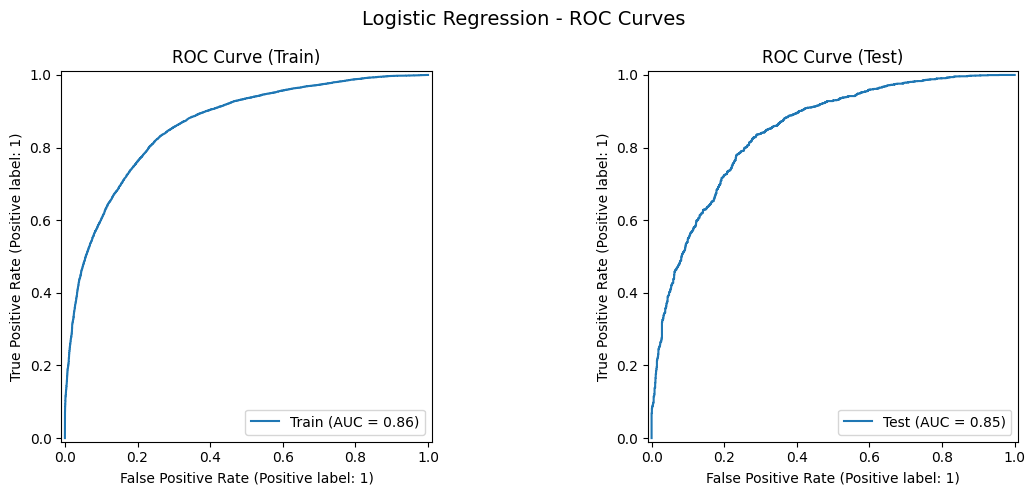

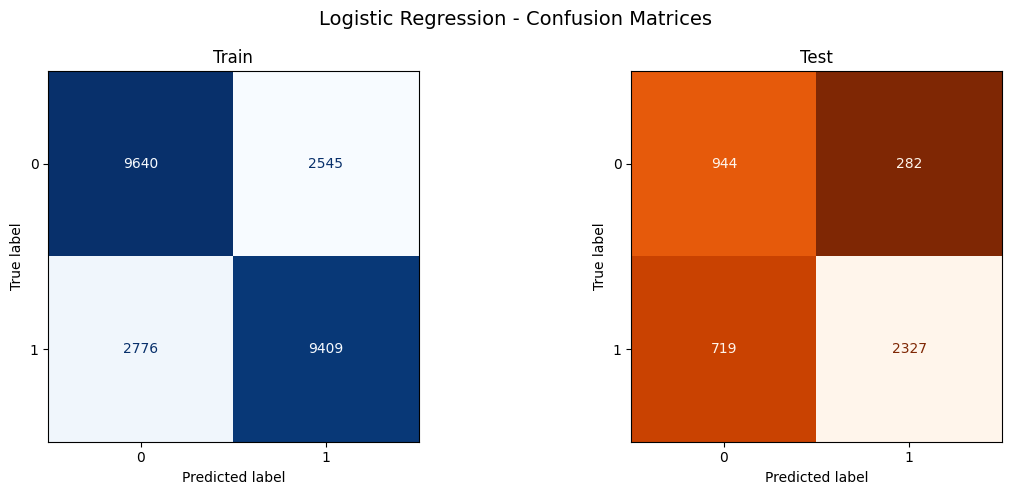

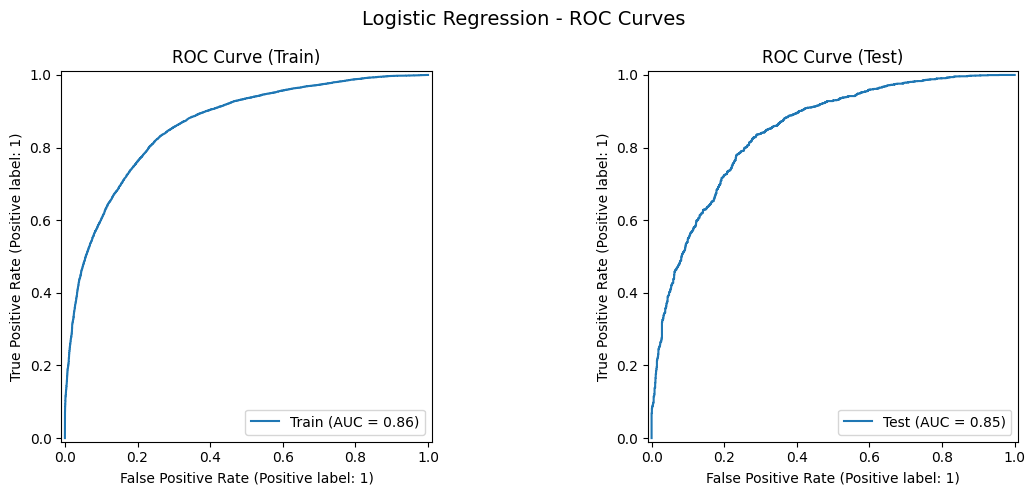


Top features for Logistic Regression (coefficients):
 no_of_special_requests               1.159833
market_segment_type_Offline          0.777825
market_segment_type_Complementary    0.494199
market_segment_type_Corporate        0.250461
arrival_month                        0.167160
room_type_reserved_Room_Type 6       0.092602
no_of_week_nights                    0.080535
room_type_reserved_Room_Type 2       0.043278
room_type_reserved_Room_Type 5       0.033175
room_type_reserved_Room_Type 7       0.032827
dtype: float64


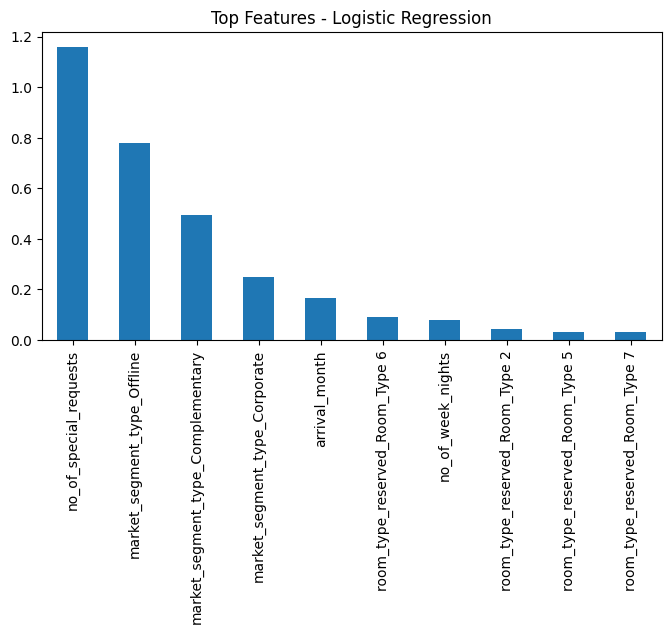

****************************************************************************************************
************ Started KNN ************


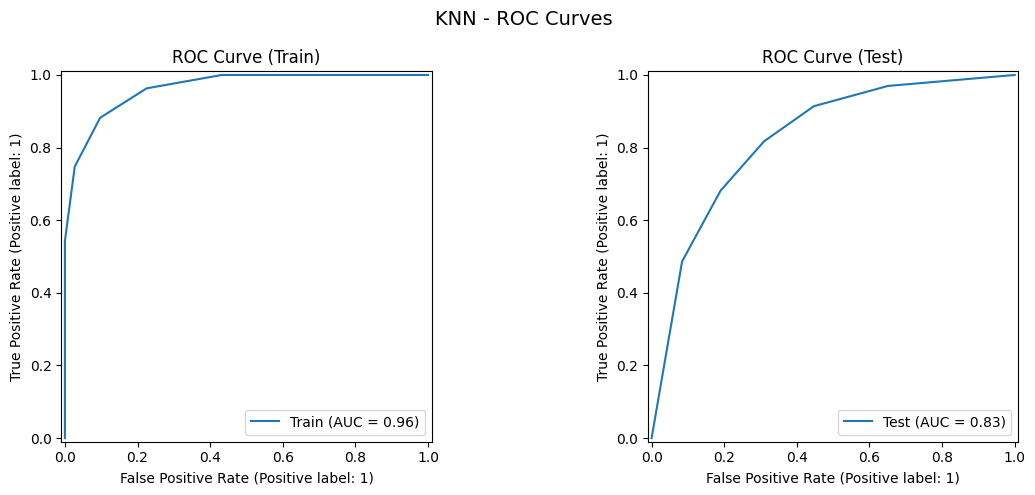

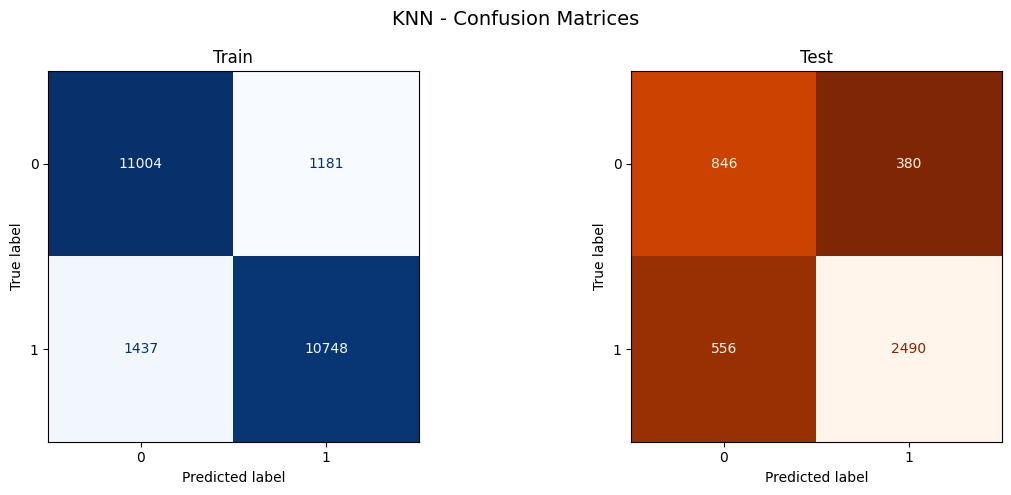

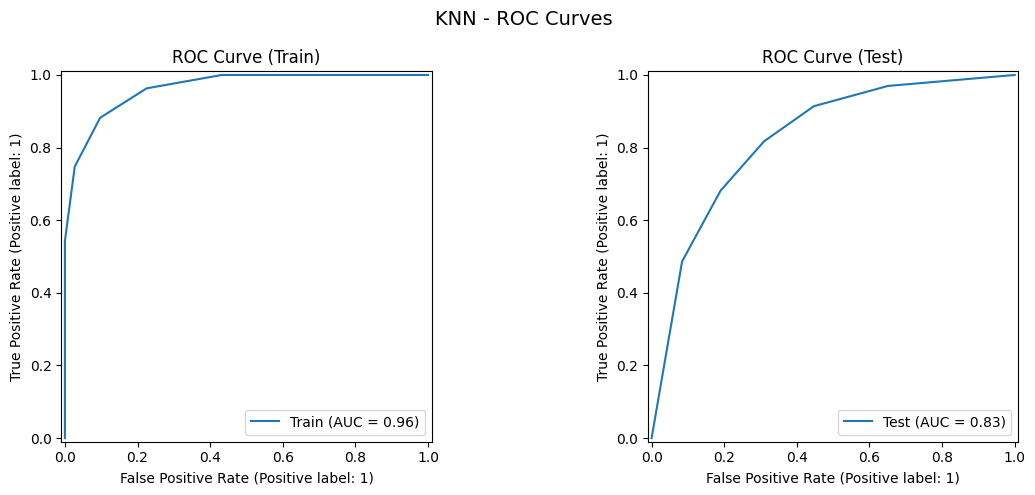

Feature importance not available for KNN(no coef_ or feature_importances_ attribute)
****************************************************************************************************
************ Started SVM ************


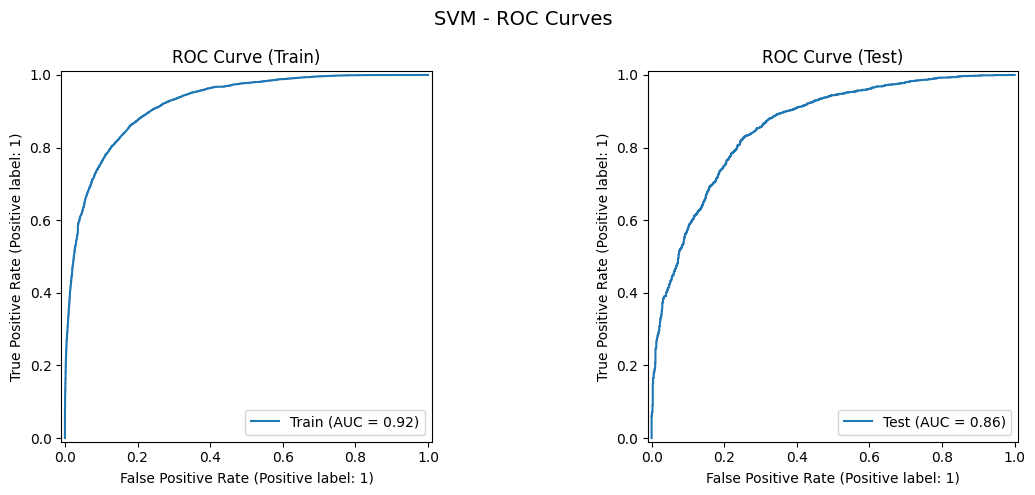

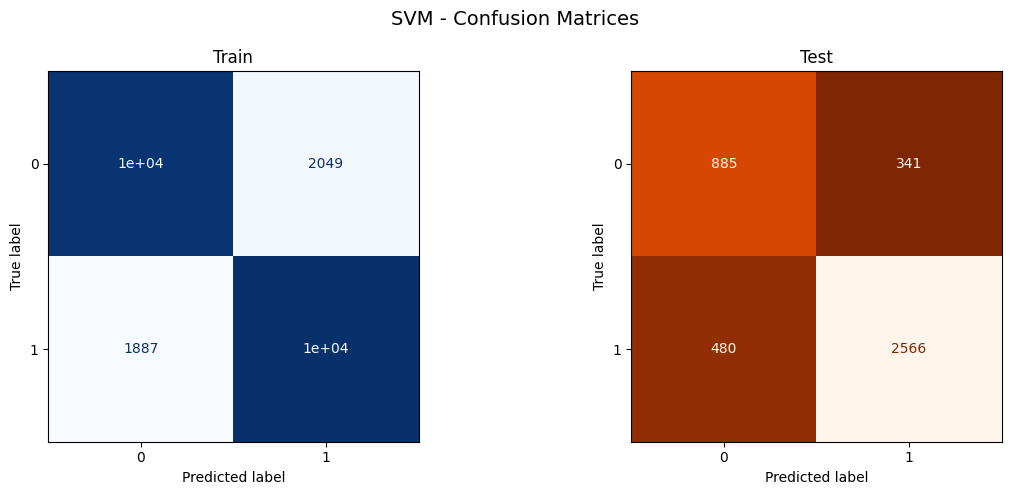

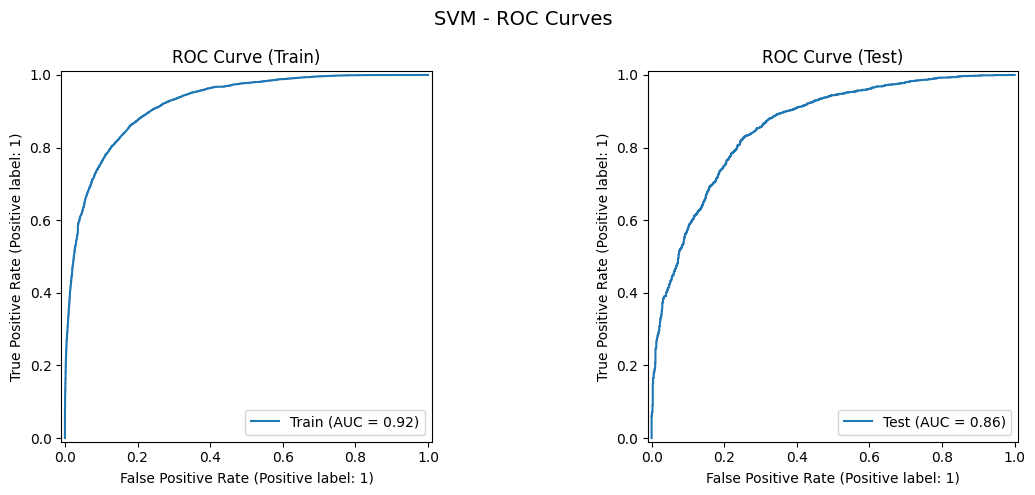

Feature importance not available for SVM(no coef_ or feature_importances_ attribute)
****************************************************************************************************
************ Started Decision Tree-Gini ************


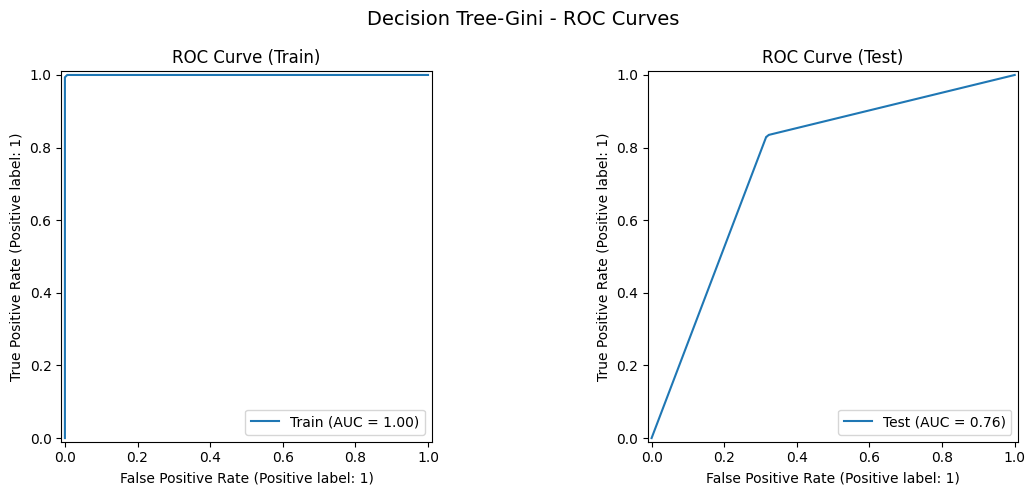

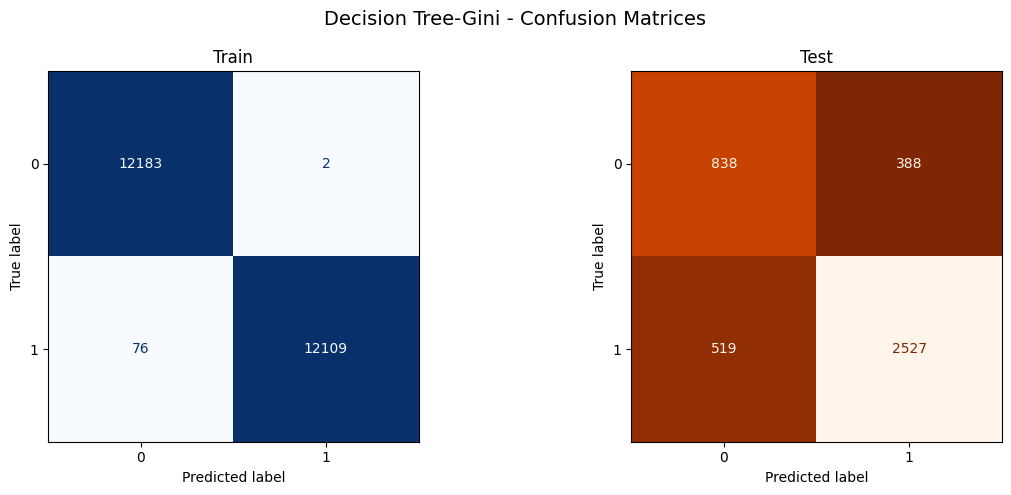

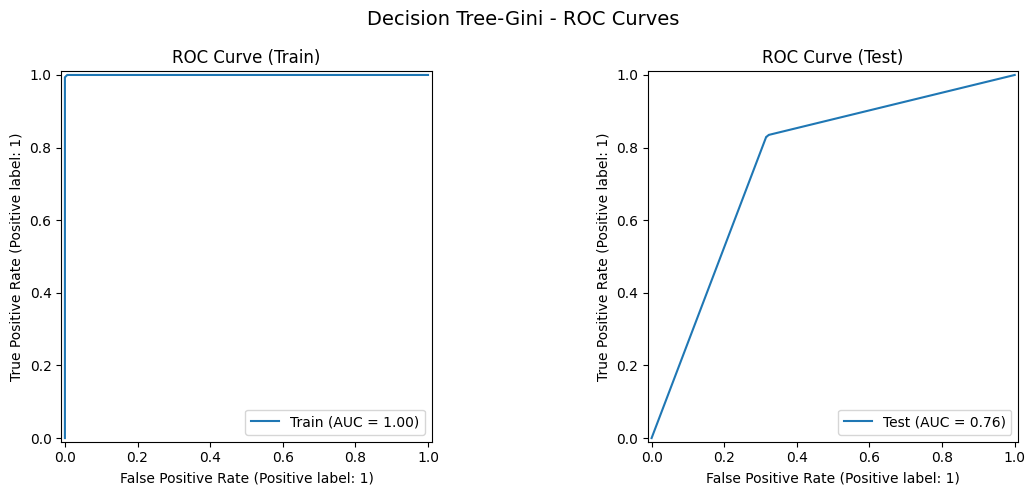


Top features for Decision Tree-Gini (feature_importances_):
 lead_time                         0.283829
no_of_special_requests            0.213767
avg_price_per_room                0.139428
market_segment_type_Offline       0.113039
arrival_date                      0.065785
arrival_month                     0.052664
no_of_week_nights                 0.036067
no_of_weekend_nights              0.034450
type_of_meal_plan_Not Selected    0.020995
market_segment_type_Corporate     0.018912
dtype: float64


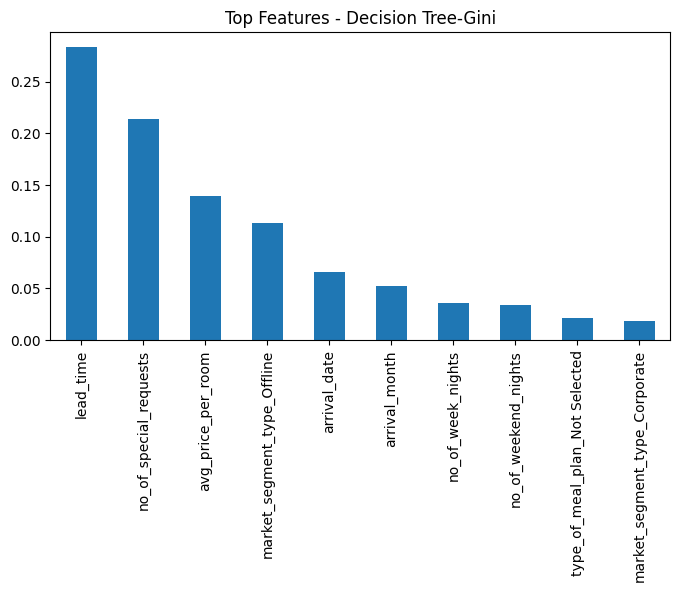

****************************************************************************************************
************ Started Decision Tree-Entropy ************


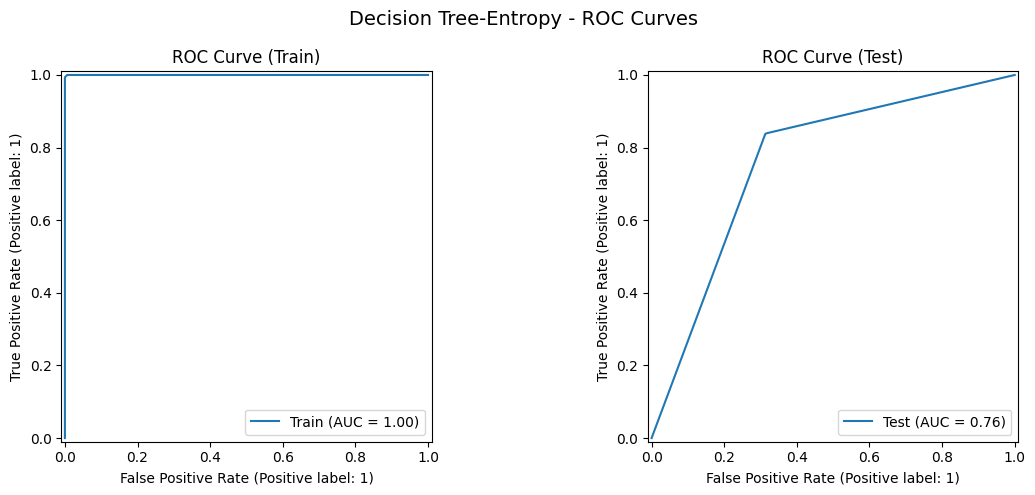

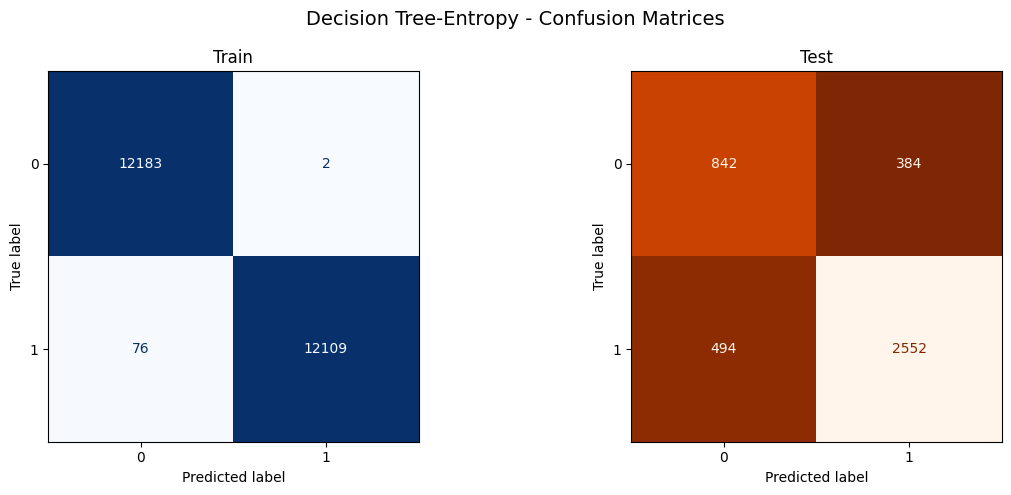

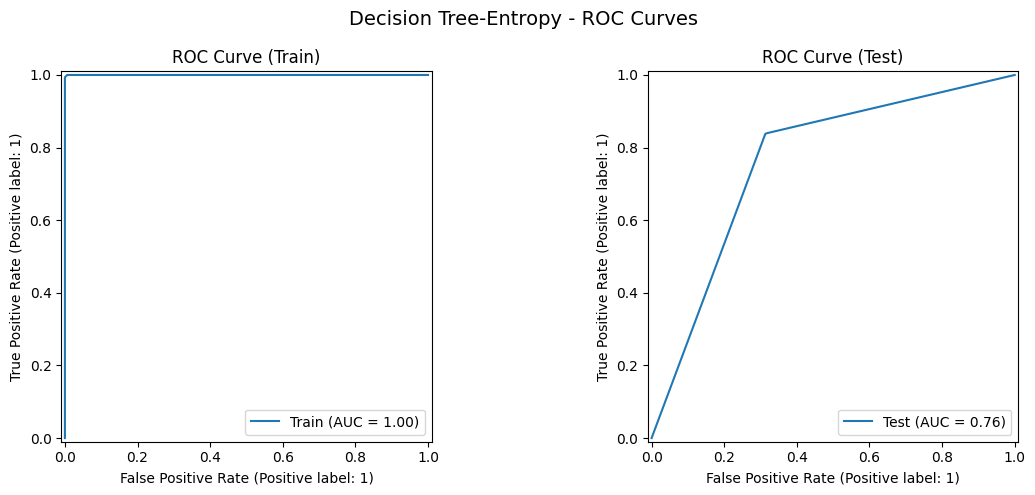


Top features for Decision Tree-Entropy (feature_importances_):
 lead_time                         0.276998
no_of_special_requests            0.195558
avg_price_per_room                0.145909
market_segment_type_Offline       0.092339
arrival_date                      0.077336
arrival_month                     0.067573
no_of_weekend_nights              0.045328
no_of_week_nights                 0.042234
type_of_meal_plan_Not Selected    0.023845
market_segment_type_Corporate     0.013197
dtype: float64


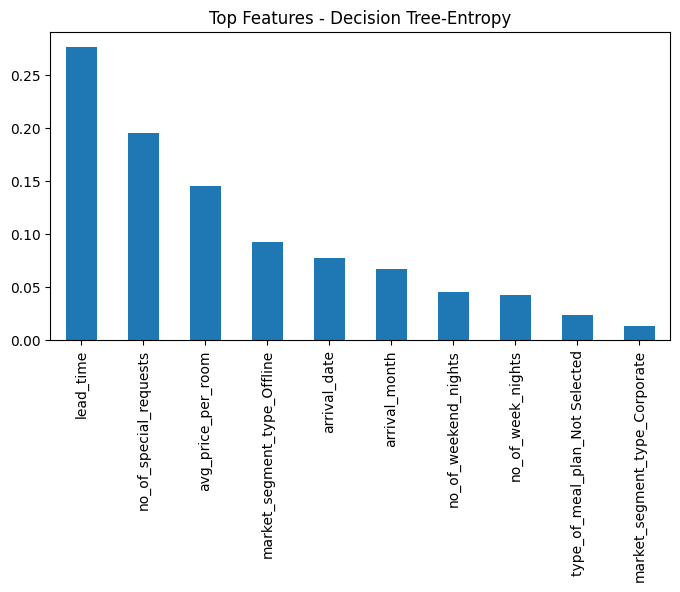

****************************************************************************************************
************ Started Random Forest ************


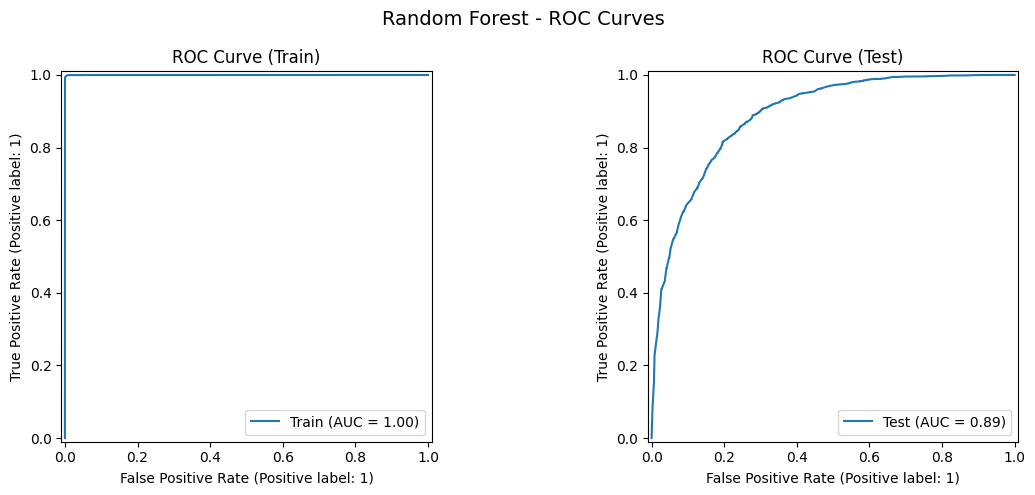

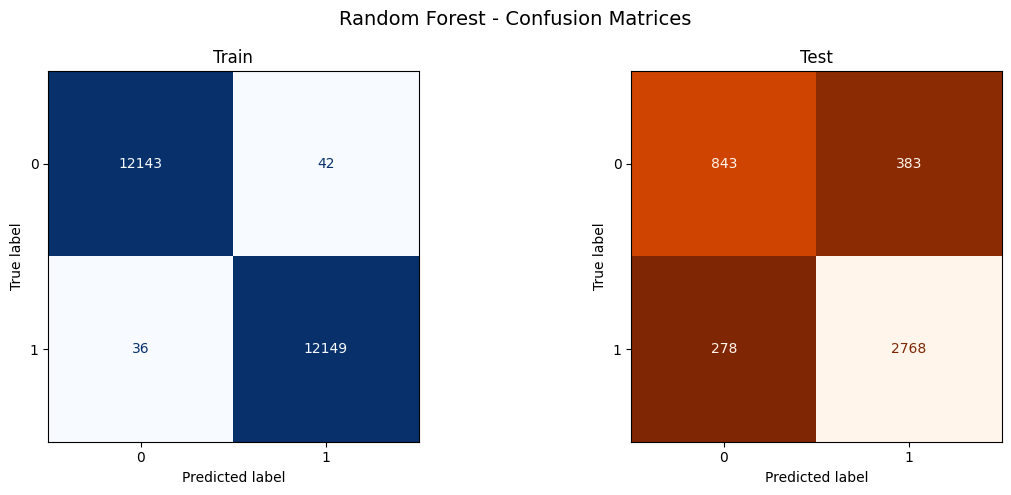

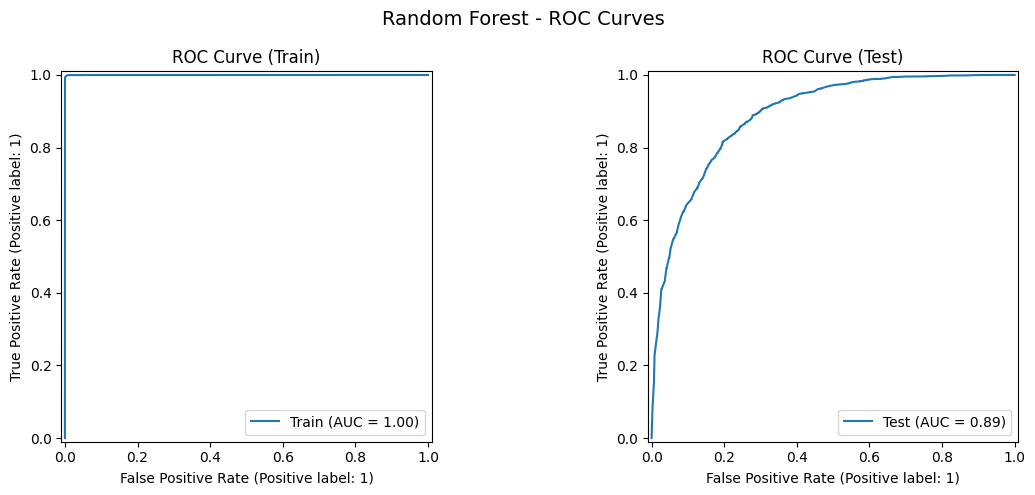


Top features for Random Forest (feature_importances_):
 lead_time                         0.243621
no_of_special_requests            0.205647
avg_price_per_room                0.135794
market_segment_type_Offline       0.074347
arrival_date                      0.073452
arrival_month                     0.071047
no_of_weekend_nights              0.068855
no_of_week_nights                 0.037826
room_type_reserved_Room_Type 4    0.025873
type_of_meal_plan_Not Selected    0.025726
dtype: float64


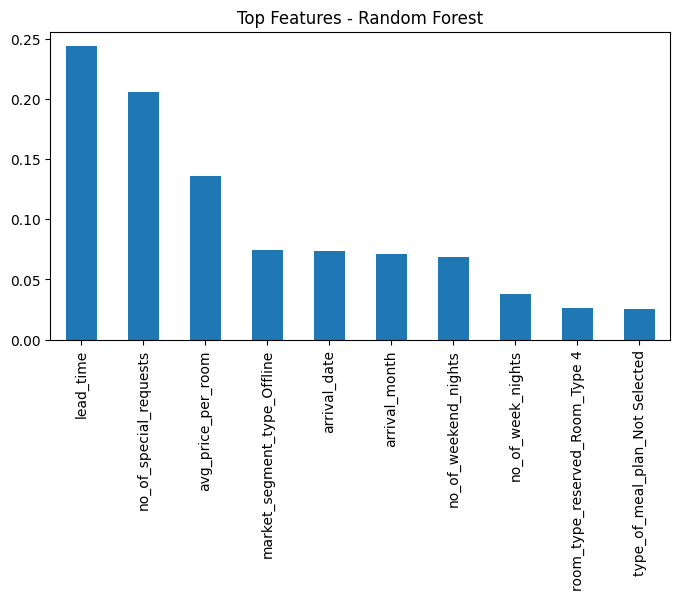

****************************************************************************************************
************ Started XGBoost ************


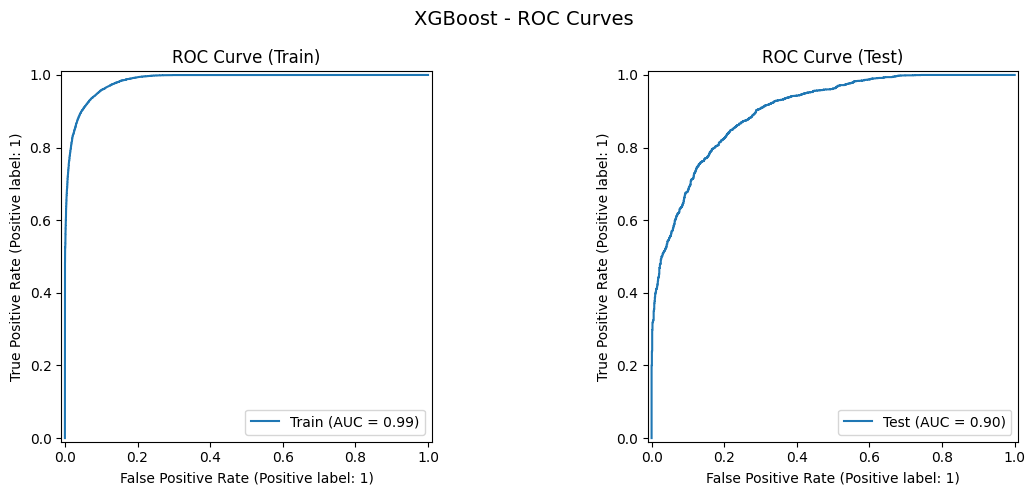

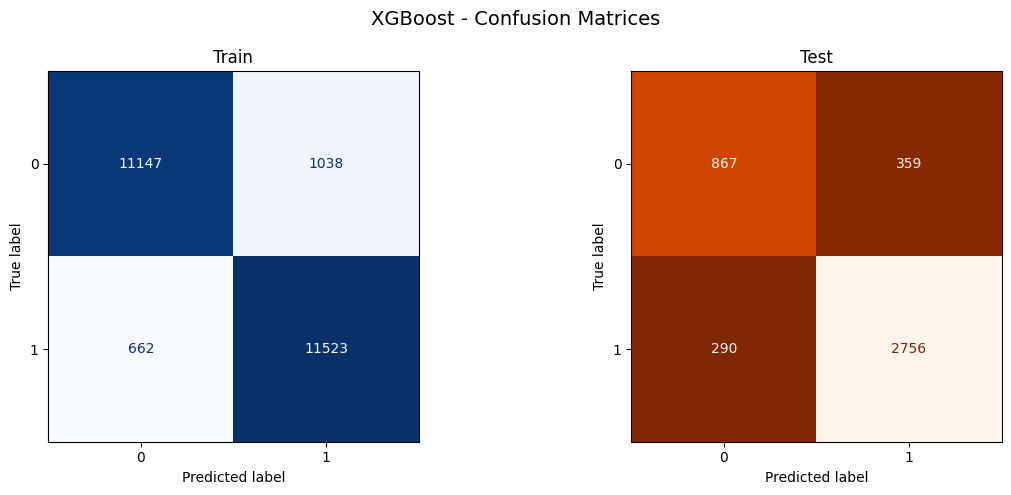

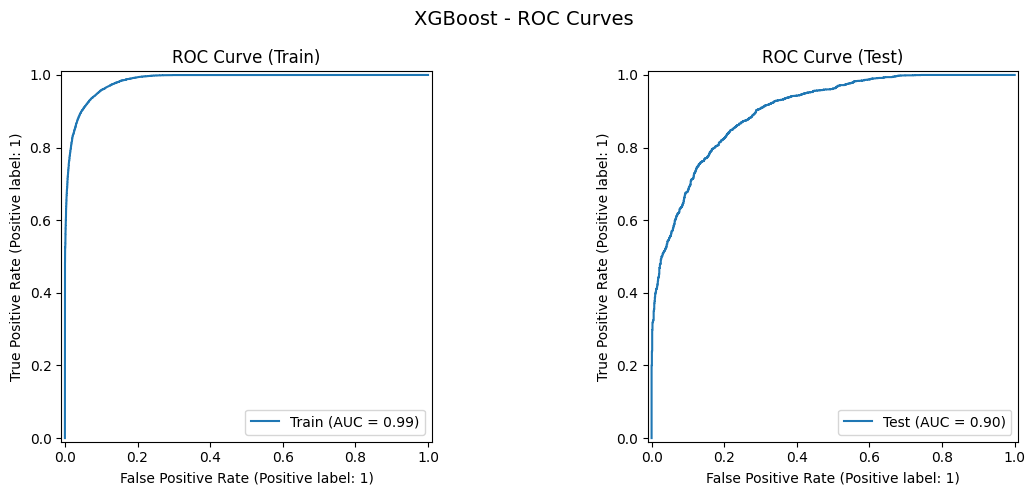


Top features for XGBoost (feature_importances_):
 market_segment_type_Offline       0.255929
no_of_special_requests            0.196488
market_segment_type_Corporate     0.136622
type_of_meal_plan_Not Selected    0.101047
no_of_weekend_nights              0.070392
lead_time                         0.063910
room_type_reserved_Room_Type 4    0.044180
avg_price_per_room                0.027196
arrival_month                     0.026282
type_of_meal_plan_Meal Plan 2     0.013063
dtype: float32


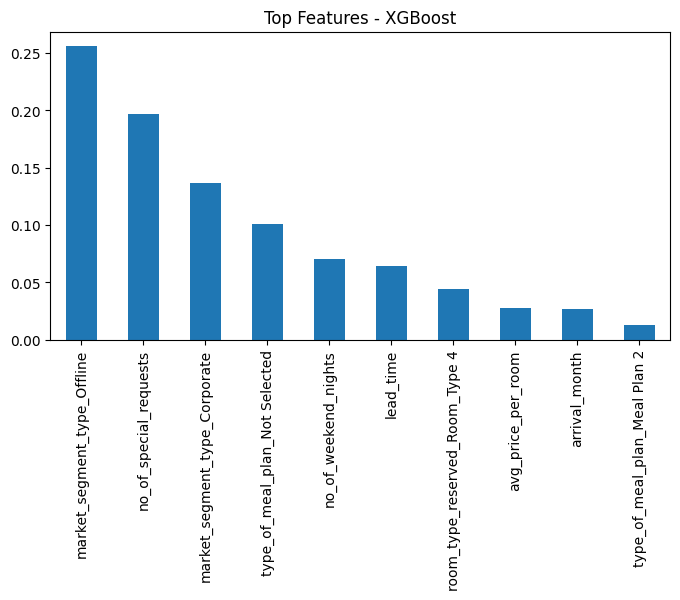

****************************************************************************************************
************ Started Naive Bayes ************


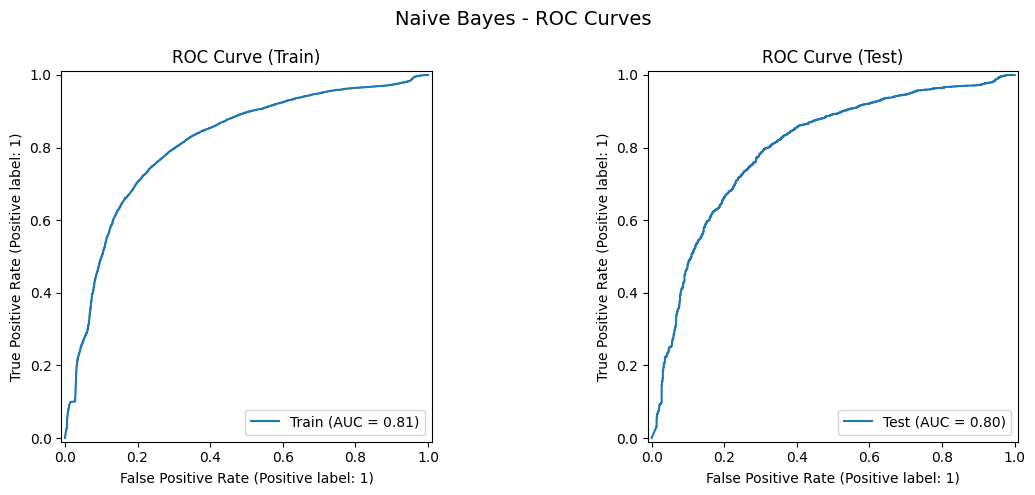

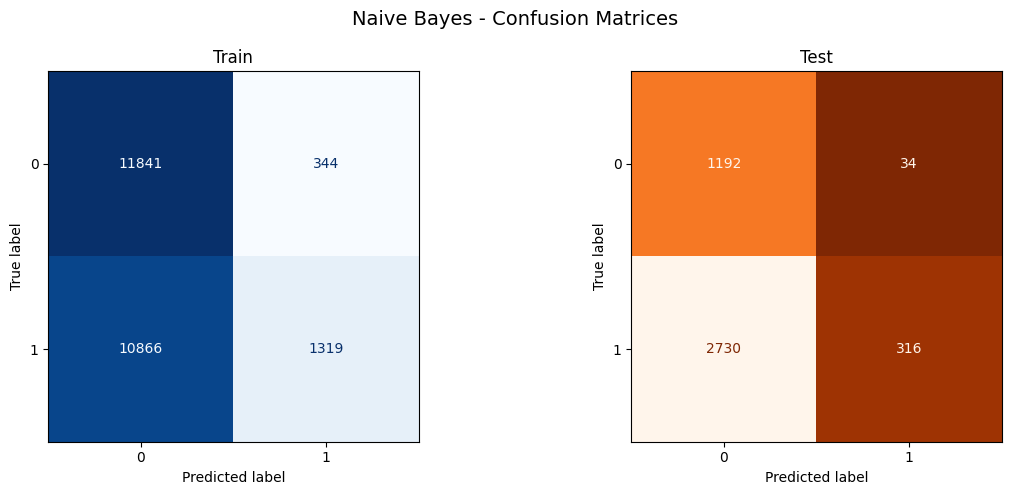

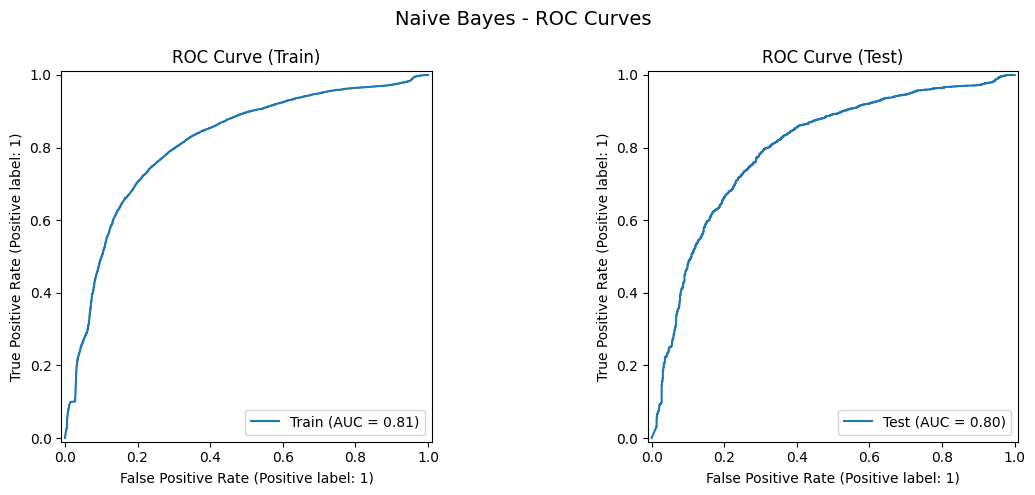

Feature importance not available for Naive Bayes(no coef_ or feature_importances_ attribute)
****************************************************************************************************
************ Started Bagging ************


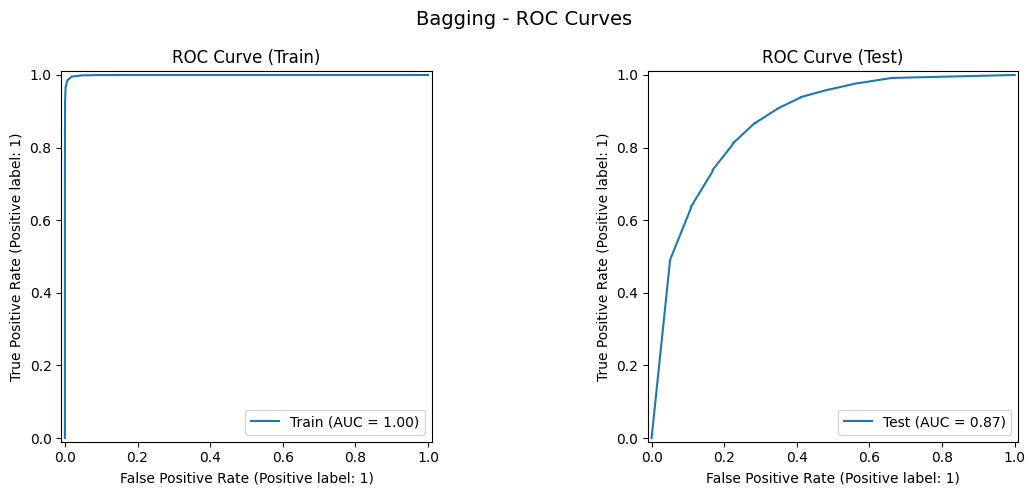

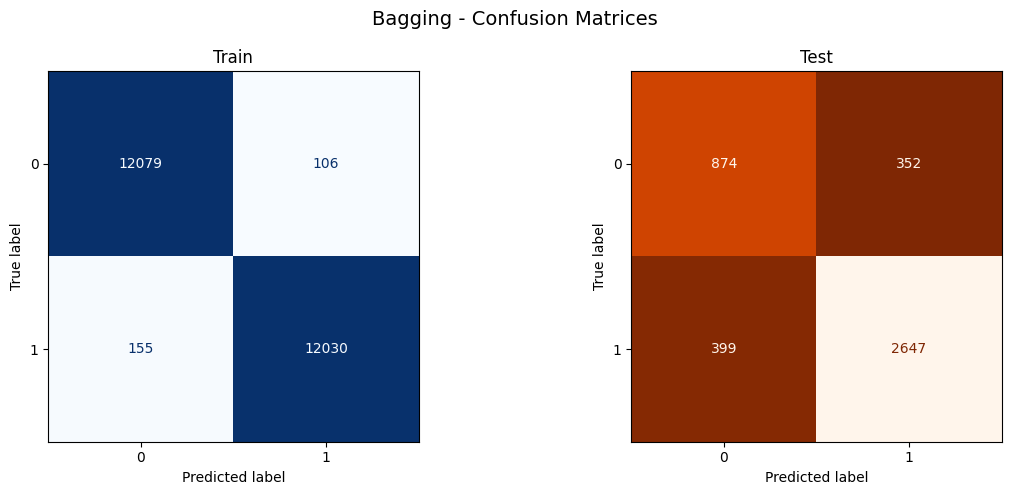

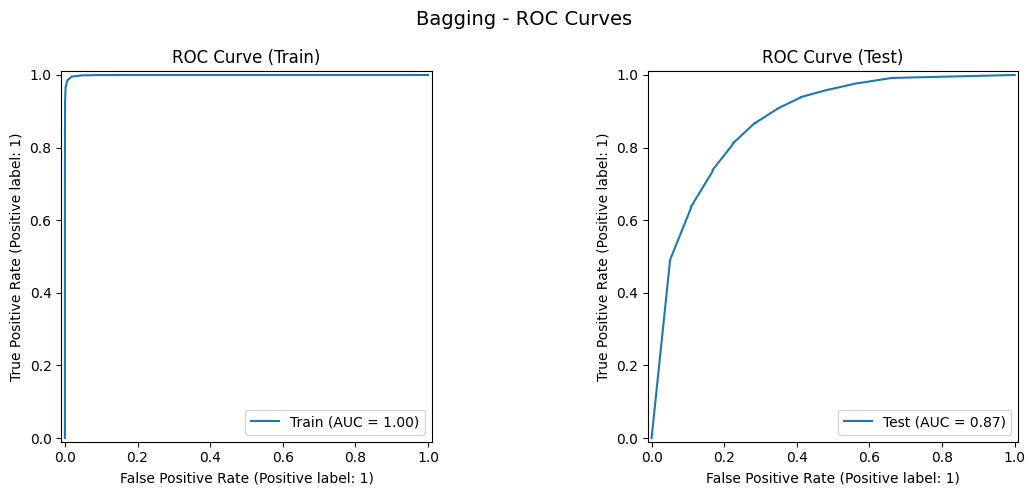

Feature importance not available for Bagging(no coef_ or feature_importances_ attribute)
****************************************************************************************************
************ Started AdaBoost ************


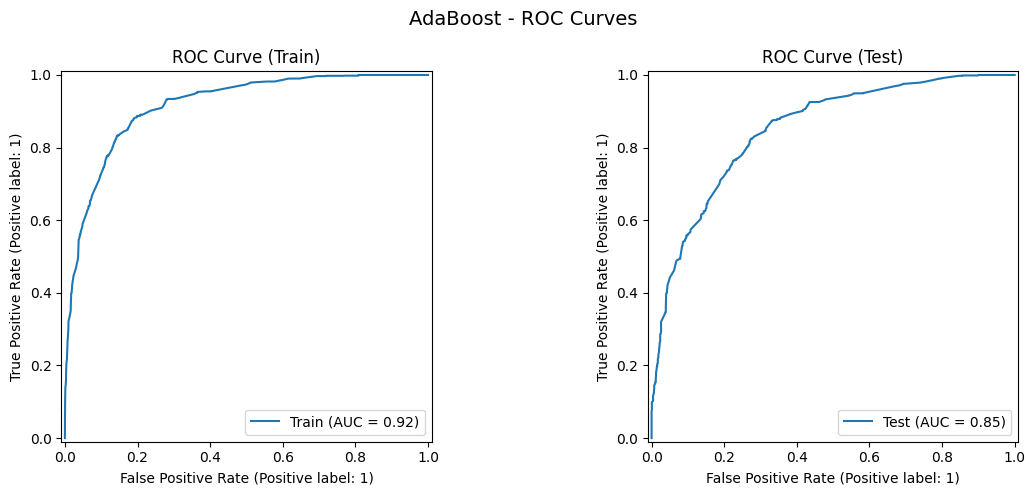

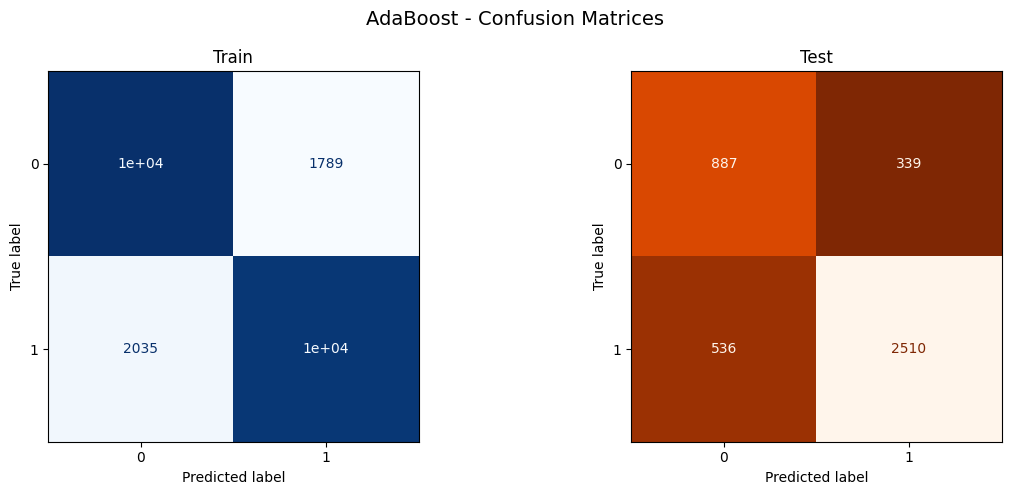

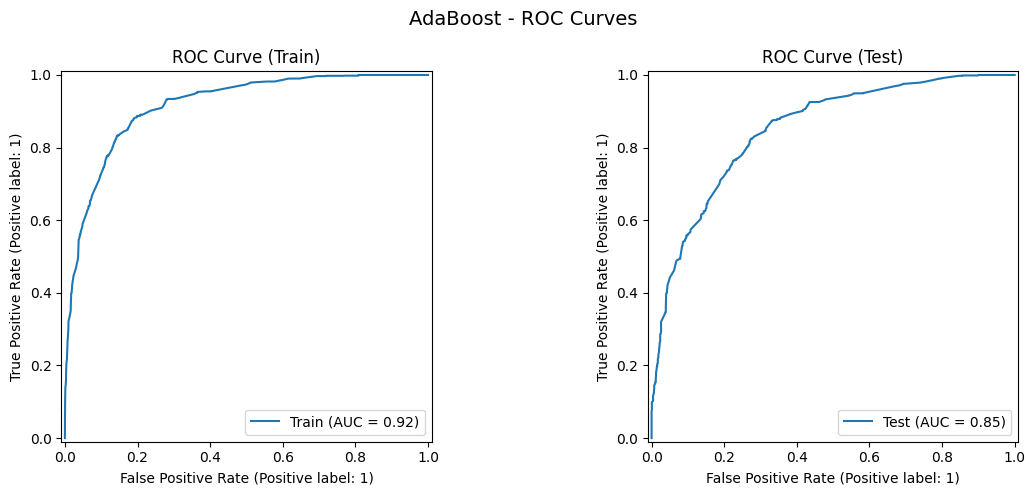


Top features for AdaBoost (feature_importances_):
 lead_time                            0.218726
no_of_special_requests               0.185403
no_of_weekend_nights                 0.140645
avg_price_per_room                   0.137113
market_segment_type_Offline          0.135055
arrival_month                        0.095826
type_of_meal_plan_Not Selected       0.056032
market_segment_type_Corporate        0.031201
required_car_parking_space           0.000000
market_segment_type_Complementary    0.000000
dtype: float64


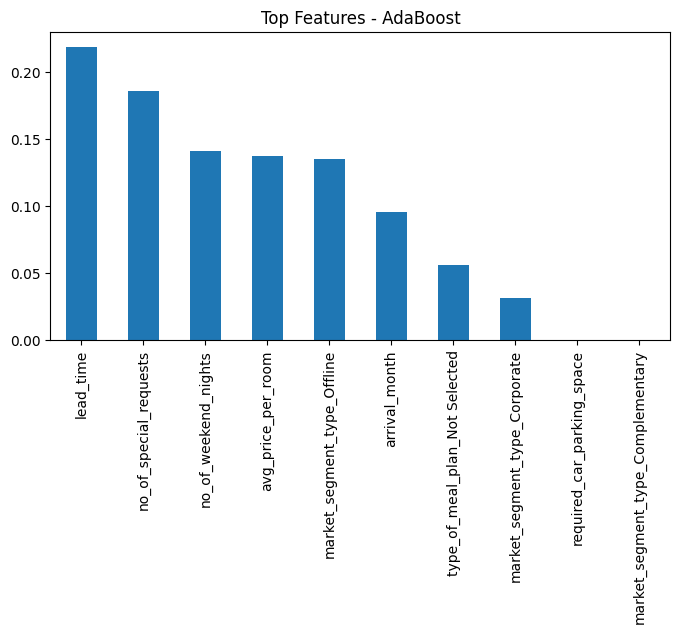

****************************************************************************************************
************ Started Gradient Boosting ************


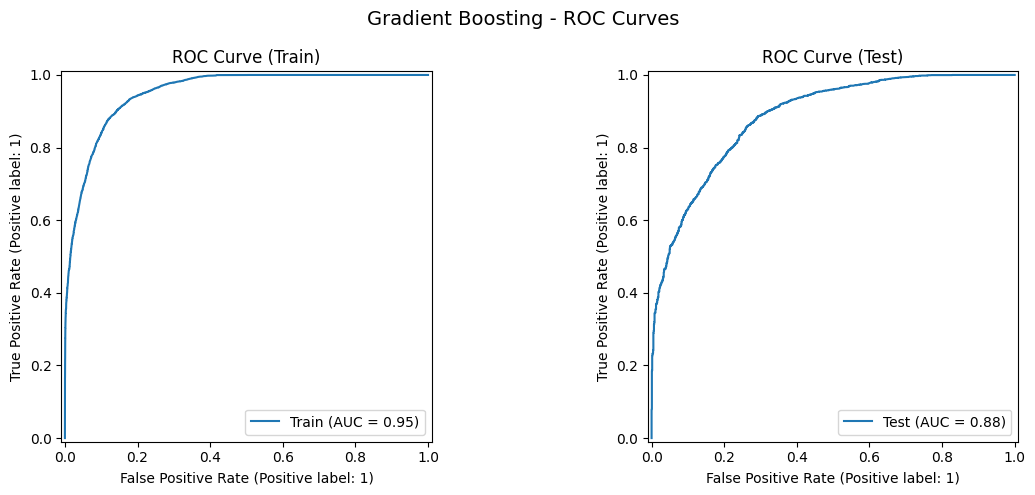

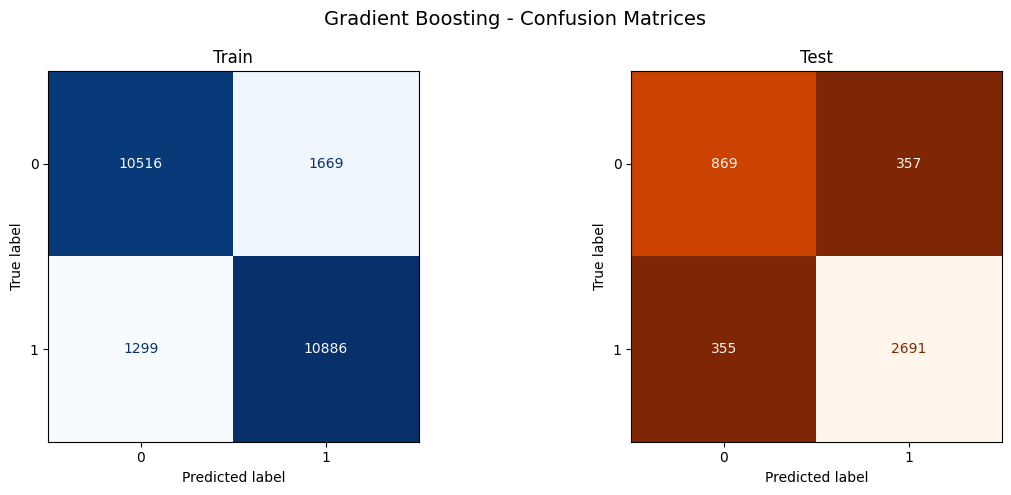

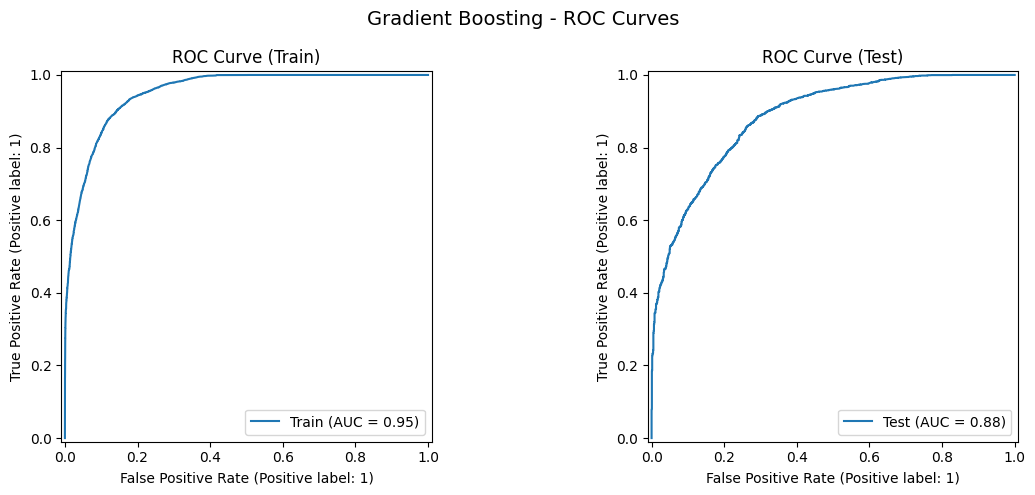


Top features for Gradient Boosting (feature_importances_):
 no_of_special_requests            0.330030
lead_time                         0.296875
market_segment_type_Offline       0.149845
avg_price_per_room                0.077593
no_of_weekend_nights              0.068985
arrival_month                     0.026557
type_of_meal_plan_Not Selected    0.020834
market_segment_type_Corporate     0.019164
room_type_reserved_Room_Type 4    0.008310
no_of_week_nights                 0.000804
dtype: float64


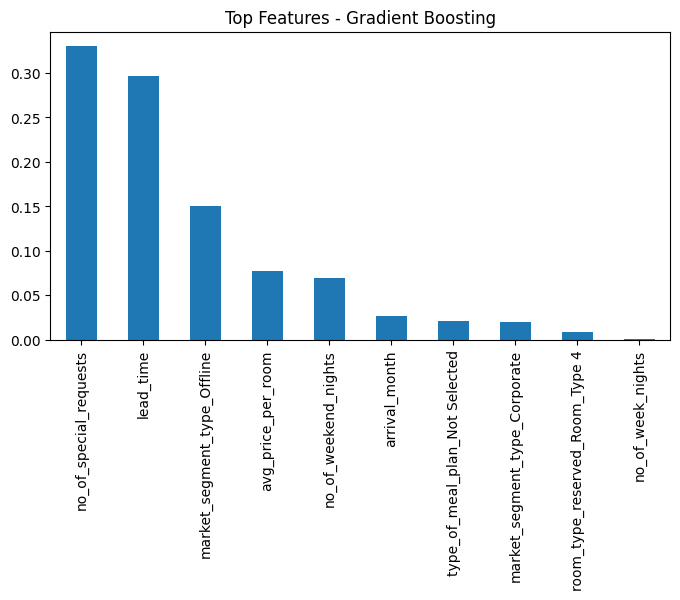

****************************************************************************************************


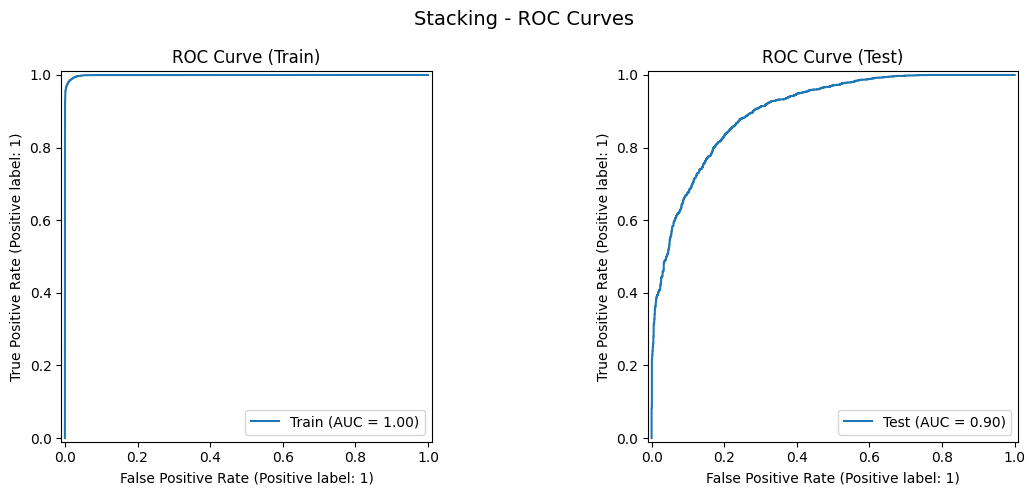

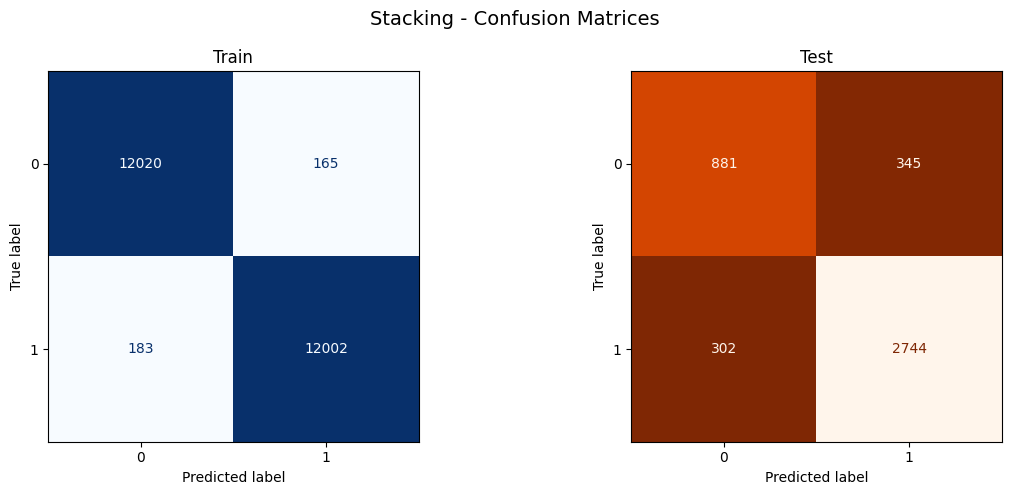

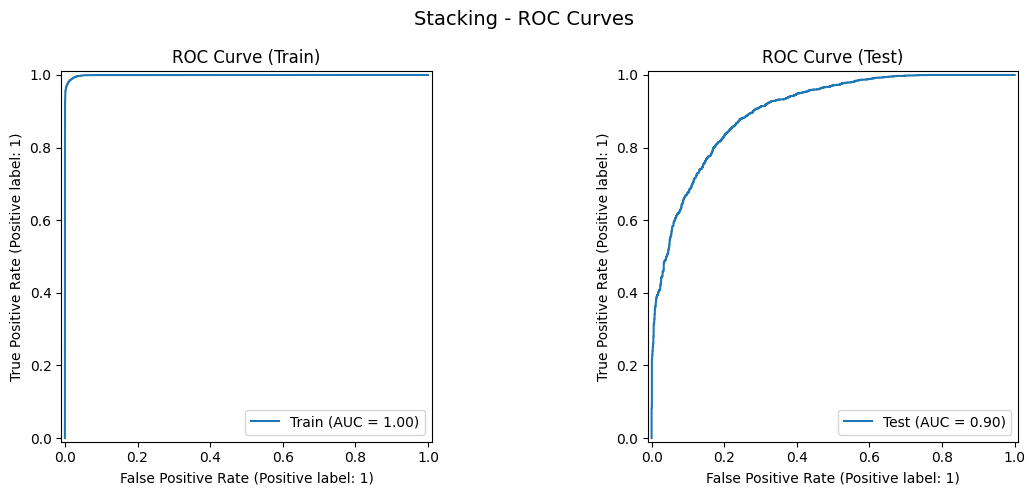

Feature importance not available for Stacking(no coef_ or feature_importances_ attribute)


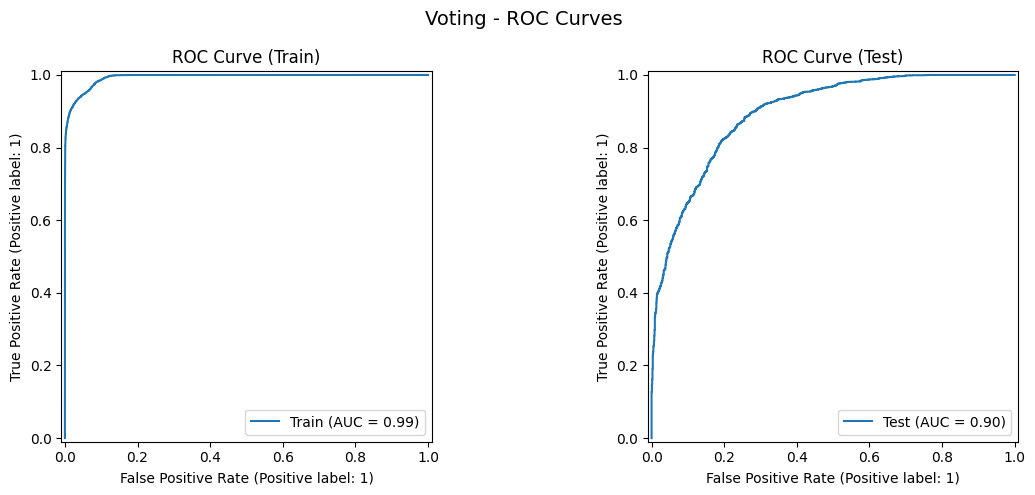

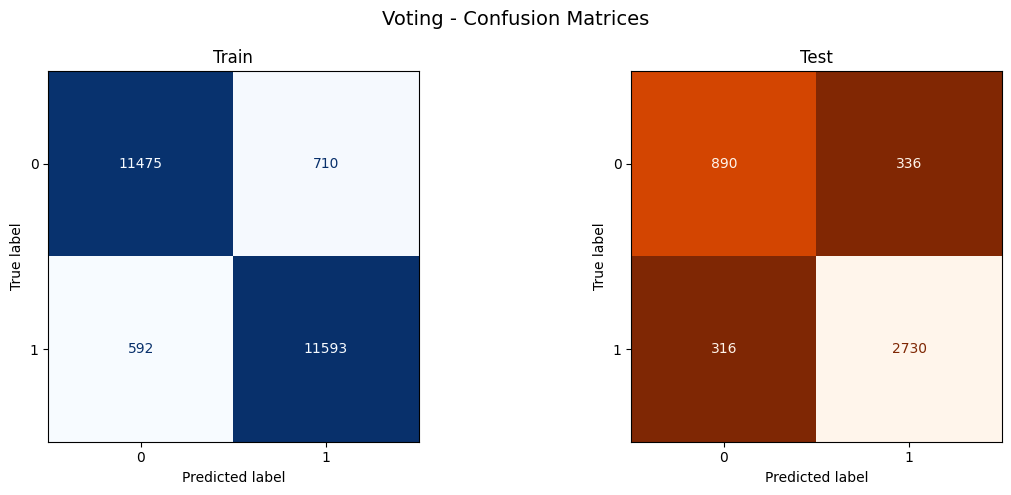

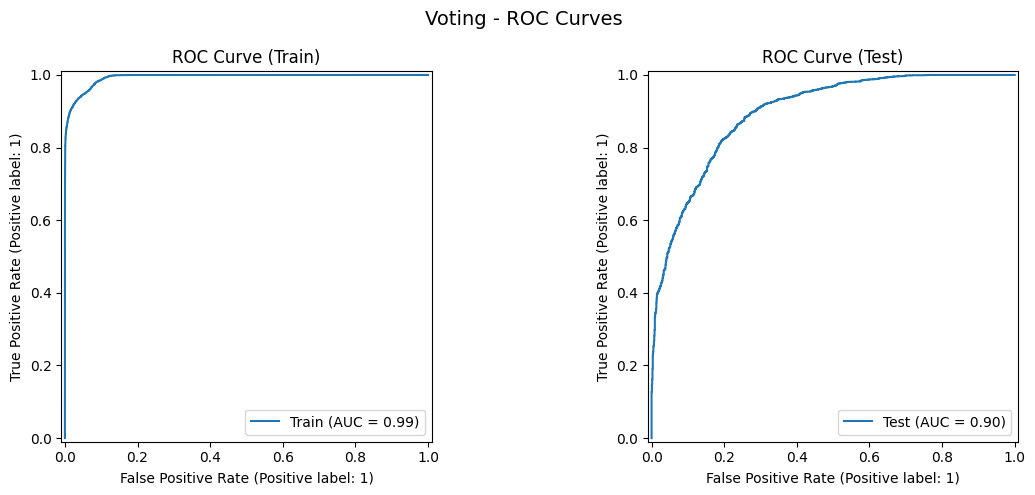

Feature importance not available for Voting(no coef_ or feature_importances_ attribute)

===================== MODEL LEADERBOARD =====================
                Algorithm  Train F1   Test F1  CV F1 Mean (10-fold)  \
0                Stacking  0.985720  0.847728              0.895286   
1                  Voting  0.946572  0.847000              0.891014   
2                 XGBoost  0.930225  0.846732              0.888734   
3           Random Forest  0.996799  0.843121              0.893786   
4       Gradient Boosting  0.878183  0.833293              0.873822   
5                 Bagging  0.989290  0.825174              0.878829   
6                     SVM  0.838483  0.810730              0.828780   
7                AdaBoost  0.843070  0.799372              0.837216   
8   Decision Tree-Entropy  0.996799  0.796998              0.852552   
9      Decision Tree-Gini  0.996799  0.790738              0.848130   
10                    KNN  0.892561  0.784976              0.830728 

,Algorithm,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1,CV F1 Mean (10-fold),CV F1 Std (10-fold),Overfitting Risk
0,Stacking,0.985720,0.985721,0.985720,0.985720,0.848549,0.847103,0.848549,0.847728,0.895286,0.066939,Medium
1,Voting,0.946574,0.946616,0.946574,0.946572,0.847378,0.846665,0.847378,0.847000,0.891014,0.064685,Medium
2,XGBoost,0.930242,0.930652,0.930242,0.930225,0.848081,0.845894,0.848081,0.846732,0.888734,0.070766,Low
3,Random Forest,0.996799,0.996799,0.996799,0.996799,0.845272,0.842164,0.845272,0.843121,0.893786,0.073070,Medium
4,Gradient Boosting,0.878211,0.878560,0.878211,0.878183,0.833333,0.833252,0.833333,0.833293,0.873822,0.067184,Low
5,Bagging,0.989290,0.989298,0.989290,0.989290,0.824204,0.826361,0.824204,0.825174,0.878829,0.063535,Medium
6,SVM,0.838490,0.838550,0.838490,0.838483,0.807818,0.815443,0.807818,0.810730,0.828780,0.041756,Low
7,AdaBoost,0.843086,0.843226,0.843086,0.843070,0.795178,0.807061,0.795178,0.799372,0.837216,0.052274,Low
8,Decision Tree-Entropy,0.996799,0.996818,0.996799,0.996799,0.794476,0.800629,0.794476,0.796998,0.852552,0.070146,Medium
9,Decision Tree-Gini,0.996799,0.996818,0.996799,0.996799,0.787687,0.795334,0.787687,0.790738,0.848130,0.070649,Medium


In [259]:
model_eval = evaluate_models(
    X_train_res,
    X_test,
    y_train_res,
    y_test,
    X_train_scaled,
    X_test_scaled,
    cv=10,
    tune_hyperparameters=False,
)

display(model_eval)

#### Save top performing model for deployment (joblib)

#### Generate joblib for deployment

#### Save Top Performing Model as Joblib (Deployment Artifact)

In [ ]:
import os
import joblib
from xgboost import XGBClassifier
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import roc_auc_score
import pandas as pd

# Re-fit per-column PowerTransformers on IQR-capped raw data
_orig = pd.read_csv('artifacts/raw/train_data/train.csv').drop(columns=['Booking_ID']).drop_duplicates()
for c in cols_to_transform:
    _Q1 = _orig[c].quantile(0.25)
    _Q3 = _orig[c].quantile(0.75)
    _IQR = _Q3 - _Q1
    _orig[c] = _orig[c].clip(lower=_Q1 - 1.5 * _IQR, upper=_Q3 + 1.5 * _IQR)

power_transformers = {}
for c in cols_to_transform:
    _pt = PowerTransformer(method='yeo-johnson', standardize=False)
    _pt.fit(_orig[[c]])
    power_transformers[c] = _pt

# Retrain XGBoost (best model) on SMOTE-resampled data
xgb_final = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_final.fit(X_train_res, y_train_res)

y_pred_proba = xgb_final.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"XGBoost Test ROC-AUC: {roc_auc:.4f}")

# Bundle model + all preprocessing artifacts for deployment
bundle = {
    'model_name': 'XGBoost',
    'model': xgb_final,
    'feature_columns': list(X_train_res.columns),
    'ohe_encoder': ohe,
    'label_encoder': le,
    'power_transformers': power_transformers,
    'cols_to_transform': cols_to_transform,
    'drop_columns_after_encoding': ['market_segment_type_Online'],
    'uses_scaler': False,
    'scaler': scaler,
    'metrics': {'test_roc_auc': round(roc_auc, 4)}
}

os.makedirs('artifacts/model', exist_ok=True)
save_path = 'artifacts/model/best_model.joblib'
joblib.dump(bundle, save_path)
print(f"Model bundle saved to: {save_path}")